# ML Predictor Comparison: Baseline vs Probability Filter

This notebook compares the original predictor in `ML_predictor.py` with the probability-aware predictor in `ML_predictor_probability.py`.

Both strategies use the same data, walk-forward training window, feature grid, signal thresholds, backtester, and execution settings. The probability strategy uses its default `probability_threshold=0.60`, so it assigns a non-zero weight only when its most likely class has probability strictly above 60%.

## 1. Setup

In [17]:
from pathlib import Path
import sys
import time
import json
import itertools
import warnings

from joblib import Parallel, delayed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

cwd = Path.cwd().resolve()
repo_root = cwd
while repo_root.name != "Bluegrey" and repo_root.parent != repo_root:
    repo_root = repo_root.parent

ml_dir = repo_root / "research" / "Mateo" / "ML_predictor"
src_dir = repo_root / "src"
for path in [repo_root, src_dir, ml_dir]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from ML_predictor import MLPredictorStrategy as BaselineStrategy
from ML_predictor_probability import MLPredictorStrategy as ProbabilityStrategy
from src.vector_backtester_Mateo import PortfolioVectorEngine

print(f"Repo root: {repo_root}")
print(f"ML directory: {ml_dir}")

Repo root: /Users/mateo/Bluegrey
ML directory: /Users/mateo/Bluegrey/research/Mateo/ML_predictor


## 2. Grid Specification


The requested grid contains 72 runs: two strategies × nine `n_features` values × four `signal_threshold` values. `training_years` is fixed at 10.

In [18]:
SYMBOL = "ECH"
ASSET_CLASS = "STK"
INITIAL_CAPITAL = 1_000_000
EXECUTION_DELAY = 1

STRATEGIES = {
    "baseline": BaselineStrategy,
    "probability_60pct": ProbabilityStrategy,
}
TRAINING_YEARS = 10
N_FEATURES_GRID = list(range(1, 20)) \
+ list(range(20, 50, 5)) \
+ list(range(50, 100, 10)) \
+ list(range(100, 201, 20))
SIGNAL_THRESHOLD_GRID = [0.000, 0.001, 0.002, 0.003, 0.004, 0.005]
PROBABILITY_THRESHOLD = 0.60

COMMON_PARAMS = {
    "symbol": SYMBOL,
    "start_date": "2025-01-01",
    "end_date": "2026-01-01",
    "training_years": TRAINING_YEARS,
    "download_data": False,
    "position_size": 1.0,
    "max_iter": 5000,
    "verbose": False,
}

RUN_GRID = True
N_JOBS = 8
PARALLEL_VERBOSE = 10
SHOW_PROGRESS = False
SAVE_ARTIFACTS = True

OUTPUT_DIR = ml_dir / "test_probability_strategy_comparison_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

grid_cases = list(itertools.product(STRATEGIES, N_FEATURES_GRID, SIGNAL_THRESHOLD_GRID))
assert N_FEATURES_GRID == [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,\
                            25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100, 120, 140, 160, 180, 200]
assert SIGNAL_THRESHOLD_GRID == [0.000, 0.001, 0.002, 0.003, 0.004, 0.005]
assert len(grid_cases) == 432

print(f"Grid cases: {len(grid_cases)} ({len(grid_cases) // len(STRATEGIES)} matched points per strategy)")
print(f"Output directory: {OUTPUT_DIR}")

Grid cases: 432 (216 matched points per strategy)
Output directory: /Users/mateo/Bluegrey/research/Mateo/ML_predictor/test_probability_strategy_comparison_outputs


## 3. Helper Functions


These helpers follow the PCA comparison notebook's conventions for run IDs, performance statistics, artifact persistence, and self-contained single-case execution.

In [19]:
def safe_value(value):
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value.is_integer():
            return str(int(value))
        return f"{value:g}".replace(".", "p")
    return str(value)


def make_run_id(symbol: str, strategy_name: str, n_features: int, signal_threshold: float) -> str:
    return (
        f"{symbol}_strategy-{strategy_name}"
        f"_features-{n_features}"
        f"_sig-{safe_value(signal_threshold)}"
    )


def annualized_sharpe(returns: pd.Series, periods_per_year: int = 252) -> float:
    returns = returns.dropna()
    volatility = returns.std()
    if volatility == 0 or np.isnan(volatility):
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / volatility


def annualized_sortino(returns: pd.Series, periods_per_year: int = 252) -> float:
    returns = returns.dropna()
    downside_volatility = returns[returns < 0].std()
    if downside_volatility == 0 or np.isnan(downside_volatility):
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / downside_volatility


def max_drawdown(equity: pd.Series) -> float:
    return (equity / equity.cummax() - 1.0).min()


def summarize_performance(
    run_id: str,
    strategy_name: str,
    params: dict,
    stats: pd.DataFrame,
    weights: pd.DataFrame,
    predictions: pd.DataFrame,
    elapsed_seconds: float,
) -> dict:
    gross_return_pct = (stats["gross_equity"].iloc[-1] / INITIAL_CAPITAL - 1.0) * 100
    net_return_pct = (stats["net_equity"].iloc[-1] / INITIAL_CAPITAL - 1.0) * 100
    benchmark_return_pct = (stats["cum_benchmark"].iloc[-1] - 1.0) * 100
    gross_bar_returns = stats["gross_returns"].iloc[1:]
    exposure = weights.abs().sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(0)
    prediction_counts = predictions["prediction"].value_counts(normalize=True).sort_index() * 100
    max_probability = predictions.get("max_probability", pd.Series(np.nan, index=predictions.index))
    passed_filter = predictions.get("passes_probability_threshold", pd.Series(True, index=predictions.index))

    return {
        "run_id": run_id,
        "strategy": strategy_name,
        "symbol": params["symbol"],
        "n_features": params["n_features"],
        "signal_threshold": params["signal_threshold"],
        "training_years": params["training_years"],
        "probability_threshold": params.get("probability_threshold", np.nan),
        "gross_return_pct": gross_return_pct,
        "net_return_pct": net_return_pct,
        "benchmark_return_pct": benchmark_return_pct,
        "excess_vs_benchmark_pct": net_return_pct - benchmark_return_pct,
        "max_drawdown_pct": max_drawdown(stats["net_equity"]) * 100,
        "net_sharpe": annualized_sharpe(stats["net_returns"]),
        "net_sortino": annualized_sortino(stats["net_returns"]),
        "win_rate_pct": (gross_bar_returns > 0).mean() * 100,
        "loss_rate_pct": (gross_bar_returns < 0).mean() * 100,
        "zero_rate_pct": (gross_bar_returns == 0).mean() * 100,
        "active_days_pct": (exposure > 0).mean() * 100,
        "long_days_pct": (weights.sum(axis=1) > 0).mean() * 100,
        "short_days_pct": (weights.sum(axis=1) < 0).mean() * 100,
        "flat_days_pct": (weights.sum(axis=1) == 0).mean() * 100,
        "average_abs_exposure": exposure.mean(),
        "average_daily_turnover": turnover.mean(),
        "total_fees_paid": stats["cumulative_costs"].iloc[-1],
        "prediction_minus1_pct": prediction_counts.get(-1.0, 0.0),
        "prediction_0_pct": prediction_counts.get(0.0, 0.0),
        "prediction_plus1_pct": prediction_counts.get(1.0, 0.0),
        "mean_max_probability": max_probability.mean(),
        "median_max_probability": (max_probability.median() if max_probability.notna().any() else np.nan),
        "passes_probability_threshold_pct": passed_filter.mean() * 100,
        "elapsed_seconds": elapsed_seconds,
    }

In [20]:
def save_case_artifacts(run_id: str, artifacts: dict) -> None:
    run_dir = OUTPUT_DIR / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    artifacts["stats"].to_pickle(run_dir / "portfolio_stats.pkl")
    artifacts["weights"].to_pickle(run_dir / "weights.pkl")
    artifacts["predictions"].to_pickle(run_dir / "predictions.pkl")
    with open(run_dir / "metrics.json", "w") as file:
        json.dump(artifacts["metrics"], file, indent=2, default=str)


def run_one_case(strategy_name: str, n_features: int, signal_threshold: float) -> dict:
    run_id = make_run_id(SYMBOL, strategy_name, n_features, signal_threshold)
    print(f"Running {run_id}")
    start = time.time()

    params = {
        **COMMON_PARAMS,
        "n_features": n_features,
        "signal_threshold": signal_threshold,
    }
    if strategy_name == "probability_60pct":
        params["probability_threshold"] = PROBABILITY_THRESHOLD

    strategy = STRATEGIES[strategy_name](params=params)
    dataset = strategy.prepare_dataset()
    prediction_output = strategy.predict(dataset, show_progress=SHOW_PROGRESS)

    if isinstance(prediction_output, pd.Series):
        predictions = prediction_output.rename("prediction").to_frame()
        weights = predictions[["prediction"]].rename(columns={"prediction": SYMBOL})
        weights[SYMBOL] *= params["position_size"]
        predictions["max_probability"] = np.nan
        predictions["passes_probability_threshold"] = True
    else:
        predictions = prediction_output.copy()
        probability_columns = ["probability_-1", "probability_0", "probability_1"]
        predictions["max_probability"] = predictions[probability_columns].max(axis=1)
        predictions["passes_probability_threshold"] = predictions["max_probability"] > params["probability_threshold"]
        weights = predictions[["prediction"]].rename(columns={"prediction": SYMBOL})
        weights[SYMBOL] = weights[SYMBOL].where(predictions["passes_probability_threshold"], 0)
        weights[SYMBOL] *= params["position_size"]

    prices = dataset[["Open"]].rename(columns={"Open": SYMBOL}).loc[weights.index]
    engine = PortfolioVectorEngine(
        prices=prices,
        signals=weights,
        asset_class=ASSET_CLASS,
        initial_capital=INITIAL_CAPITAL,
        execution_delay=EXECUTION_DELAY,
    )
    stats = engine.run()
    metrics = summarize_performance(
        run_id,
        strategy_name,
        params,
        stats,
        weights,
        predictions,
        time.time() - start,
    )
    artifacts = {
        "run_id": run_id,
        "params": params,
        "weights": weights,
        "predictions": predictions,
        "prices": prices,
        "stats": stats,
        "metrics": metrics,
    }
    if SAVE_ARTIFACTS:
        save_case_artifacts(run_id, artifacts)
    return artifacts

## 4. Run the Parallel Grid

This is the expensive cell. Like the PCA comparison notebook, it uses joblib's process-based `loky` backend and saves every successful run under `test_probability_strategy_comparison_outputs/`.

In [21]:
grid_artifacts = {}
grid_metrics = []
grid_errors = []


def run_one_case_safely(case):
    strategy_name, n_features, signal_threshold = case
    run_id = make_run_id(SYMBOL, strategy_name, n_features, signal_threshold)
    try:
        artifacts = run_one_case(strategy_name, n_features, signal_threshold)
        return {"ok": True, "run_id": run_id, "artifacts": artifacts}
    except Exception as exc:
        return {
            "ok": False,
            "run_id": run_id,
            "strategy": strategy_name,
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "error": repr(exc),
        }


if RUN_GRID:
    grid_results = Parallel(n_jobs=N_JOBS, backend="loky", verbose=PARALLEL_VERBOSE)(
        delayed(run_one_case_safely)(case)
        for case in grid_cases
    )

    for result in grid_results:
        if result["ok"]:
            grid_artifacts[result["run_id"]] = result["artifacts"]
            grid_metrics.append(result["artifacts"]["metrics"])
        else:
            grid_errors.append({key: value for key, value in result.items() if key != "ok"})

metrics_df = pd.DataFrame(grid_metrics)
errors_df = pd.DataFrame(grid_errors)

metrics_df["net_return_rank"] = metrics_df["net_return_pct"].rank(method="min", ascending=False, na_option="bottom")
metrics_df["net_sharpe_rank"] = metrics_df["net_sharpe"].rank(method="min", ascending=False, na_option="bottom")
metrics_df["net_sortino_rank"] = metrics_df["net_sortino"].rank(method="min", ascending=False, na_option="bottom")
metrics_df["performance_score"] = (
    0.50 * metrics_df["net_return_rank"]
    + 0.25 * metrics_df["net_sharpe_rank"]
    + 0.25 * metrics_df["net_sortino_rank"]
)
metrics_df["performance_rank"] = metrics_df["performance_score"].rank(method="min", ascending=True).astype(int)

if SAVE_ARTIFACTS and not metrics_df.empty:
    metrics_df.to_pickle(OUTPUT_DIR / "grid_metrics.pkl")
    metrics_df.to_csv(OUTPUT_DIR / "grid_metrics.csv", index=False)
if SAVE_ARTIFACTS and not errors_df.empty:
    errors_df.to_csv(OUTPUT_DIR / "grid_errors.csv", index=False)

display(metrics_df.sort_values(["performance_rank", "performance_score", "net_return_pct"], ascending=[True, True, False]).head(10))
display(errors_df)

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


Running ECH_strategy-baseline_features-1_sig-0
Running ECH_strategy-baseline_features-1_sig-0p003
Running ECH_strategy-baseline_features-2_sig-0p001
Running ECH_strategy-baseline_features-2_sig-0
Running ECH_strategy-baseline_features-1_sig-0p001
Running ECH_strategy-baseline_features-1_sig-0p002
Running ECH_strategy-baseline_features-1_sig-0p004
Running ECH_strategy-baseline_features-1_sig-0p005
Running ECH_strategy-baseline_features-2_sig-0p002


[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:   31.6s


Running ECH_strategy-baseline_features-2_sig-0p003
Running ECH_strategy-baseline_features-2_sig-0p004
Running ECH_strategy-baseline_features-2_sig-0p005
Running ECH_strategy-baseline_features-3_sig-0
Running ECH_strategy-baseline_features-3_sig-0p001
Running ECH_strategy-baseline_features-3_sig-0p002
Running ECH_strategy-baseline_features-3_sig-0p003
Running ECH_strategy-baseline_features-3_sig-0p004


[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:  1.0min


...

[Parallel(n_jobs=8)]: Done 405 tasks      | elapsed: 165.0min


Running ECH_strategy-probability_60pct_features-140_sig-0p004
Running ECH_strategy-probability_60pct_features-140_sig-0p005
Running ECH_strategy-probability_60pct_features-160_sig-0
Running ECH_strategy-probability_60pct_features-160_sig-0p001
Running ECH_strategy-probability_60pct_features-160_sig-0p002
Running ECH_strategy-probability_60pct_features-160_sig-0p003
Running ECH_strategy-probability_60pct_features-160_sig-0p004
Running ECH_strategy-probability_60pct_features-160_sig-0p005
Running ECH_strategy-probability_60pct_features-180_sig-0
Running ECH_strategy-probability_60pct_features-180_sig-0p001
Running ECH_strategy-probability_60pct_features-180_sig-0p002
Running ECH_strategy-probability_60pct_features-180_sig-0p003
Running ECH_strategy-probability_60pct_features-180_sig-0p004
Running ECH_strategy-probability_60pct_features-180_sig-0p005
Running ECH_strategy-probability_60pct_features-200_sig-0
Running ECH_strategy-probability_60pct_features-200_sig-0p001
Running ECH_strategy

[Parallel(n_jobs=8)]: Done 432 out of 432 | elapsed: 184.5min finished


,run_id,strategy,symbol,n_features,signal_threshold,training_years,probability_threshold,gross_return_pct,net_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,net_sharpe,net_sortino,win_rate_pct,loss_rate_pct,zero_rate_pct,active_days_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,average_daily_turnover,total_fees_paid,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,mean_max_probability,median_max_probability,passes_probability_threshold_pct,elapsed_seconds,net_return_rank,net_sharpe_rank,net_sortino_rank,performance_score,performance_rank
93,ECH_strategy-baseline_features-16_sig-0p003,baseline,ECH,16,0.003,10,NaN,60.582496,54.762360,65.173061,-10.410700,-11.309419,2.054118,3.229398,53.815261,42.168675,4.016064,98.8,54.8,44.0,1.2,0.988,0.832,58201.361100,44.0,1.2,54.8,NaN,NaN,100.0,221.208240,1.0,1.0,4.0,1.75,1
87,ECH_strategy-baseline_features-15_sig-0p003,baseline,ECH,15,0.003,10,NaN,59.079112,52.807464,65.173061,-12.365597,-10.294609,1.997513,2.979905,55.020080,40.963855,4.016064,98.8,56.4,42.4,1.2,0.988,0.888,62716.483833,42.4,1.2,56.4,NaN,NaN,100.0,269.534676,2.0,2.0,5.0,2.75,2
154,ECH_strategy-baseline_features-50_sig-0p004,baseline,ECH,50,0.004,10,NaN,49.444301,43.678575,65.173061,-21.494485,-12.631626,1.763492,2.710408,48.995984,41.767068,9.236948,92.8,50.4,42.4,7.2,0.928,0.872,57657.256659,42.4,7.2,50.4,NaN,NaN,100.0,188.639966,3.0,4.0,6.0,4.00,3
142,ECH_strategy-baseline_features-40_sig-0p004,baseline,ECH,40,0.004,10,NaN,48.714014,42.767232,65.173061,-22.405828,-8.534851,1.698958,2.556664,52.208835,39.357430,8.433735,94.0,45.6,48.4,6.0,0.940,0.848,59467.821796,48.4,6.0,45.6,NaN,NaN,100.0,210.431960,4.0,5.0,7.0,5.00,4
68,ECH_strategy-baseline_features-12_sig-0p002,baseline,ECH,12,0.002,10,NaN,43.881399,38.511457,65.173061,-26.661604,-13.136906,1.542558,2.228133,54.618474,42.570281,2.811245,100.0,65.2,34.8,0.0,1.000,0.824,53699.423695,34.8,0.0,65.2,NaN,NaN,100.0,145.641255,5.0,7.0,10.0,6.75,5
161,ECH_strategy-baseline_features-60_sig-0p005,baseline,ECH,60,0.005,10,NaN,40.888689,36.189576,65.173061,-28.983485,-12.299951,1.788267,2.289067,32.931727,25.702811,41.365462,58.4,36.4,22.0,41.6,0.584,0.708,46991.138666,22.0,41.6,36.4,NaN,NaN,100.0,189.132391,9.0,3.0,8.0,7.25,6
110,ECH_strategy-baseline_features-19_sig-0p002,baseline,ECH,19,0.002,10,NaN,42.544220,37.201157,65.173061,-27.971903,-10.343428,1.502055,2.224962,53.012048,44.176707,2.811245,100.0,61.6,38.4,0.0,1.000,0.848,53430.626888,38.4,0.0,61.6,NaN,NaN,100.0,213.151849,6.0,10.0,11.0,8.25,7
98,ECH_strategy-baseline_features-17_sig-0p002,baseline,ECH,17,0.002,10,NaN,42.355933,36.957403,65.173061,-28.215658,-11.247092,1.493273,2.093955,56.626506,40.562249,2.811245,100.0,62.8,37.2,0.0,1.000,0.864,53985.306032,37.2,0.0,62.8,NaN,NaN,100.0,216.689916,7.0,11.0,13.0,9.50,8
130,ECH_strategy-baseline_features-30_sig-0p004,baseline,ECH,30,0.004,10,NaN,42.105723,36.305079,65.173061,-28.867982,-10.436483,1.542022,2.061735,51.004016,38.955823,10.040161,92.0,48.0,44.0,8.0,0.920,0.880,58006.438608,44.0,8.0,48.0,NaN,NaN,100.0,278.454438,8.0,8.0,14.0,9.50,8
75,ECH_strategy-baseline_features-13_sig-0p003,baseline,ECH,13,0.003,10,NaN,40.861229,35.783310,65.173061,-29.389750,-22.435152,1.456182,2.231449,53.012048,44.176707,2.811245,100.0,58.4,41.6,0.0,1.000,0.864,50779.191314,41.6,0.0,58.4,NaN,NaN,100.0,177.890253,10.0,12.0,9.0,10.25,10


""


## 5. Performance Leaderboards



Use performance rank to identify the best performer. Its score is `0.50 × net-return rank + 0.25 × net-Sharpe rank + 0.25 × net-Sortino rank`; lower scores and ranks are better. Then inspect drawdown, fees, activity, and turnover as secondary diagnostics. The probability-specific confidence columns are `NaN` for the baseline by design.

In [22]:
leaderboard_cols = [
    "performance_rank", "performance_score", "run_id", "strategy",
    "n_features", "signal_threshold", "probability_threshold",
    "net_return_rank", "net_sharpe_rank", "net_sortino_rank",
    "net_return_pct", "gross_return_pct", "benchmark_return_pct", "excess_vs_benchmark_pct",
    "net_sharpe", "net_sortino", "max_drawdown_pct", "total_fees_paid",
    "win_rate_pct", "loss_rate_pct", "zero_rate_pct",
    "long_days_pct", "short_days_pct", "flat_days_pct", "average_abs_exposure",
    "prediction_minus1_pct", "prediction_0_pct", "prediction_plus1_pct",
    "active_days_pct", "average_daily_turnover", "mean_max_probability",
    "passes_probability_threshold_pct", "elapsed_seconds",
]

print("Best performers by PERFORMANCE RANK")
display(metrics_df[leaderboard_cols].sort_values(["performance_rank", "performance_score", "net_return_pct"], ascending=[True, True, False]).head(15).round(3))
print("\nHighest NET RETURN (50% score component)")
display(metrics_df[leaderboard_cols].sort_values("net_return_pct", ascending=False).head(15).round(3))
print("\nHighest NET SHARPE RATIO (25% score component)")
display(metrics_df[leaderboard_cols].sort_values("net_sharpe", ascending=False).head(15).round(3))
print("\nSmallest MAX DRAWDOWN (secondary diagnostic)")
display(metrics_df[leaderboard_cols].sort_values("max_drawdown_pct", ascending=False).head(15).round(3))

best_by_strategy = metrics_df.sort_values(["performance_rank", "performance_score", "net_return_pct"], ascending=[True, True, False]).groupby("strategy").head(1)
print("\nBest performance-ranked run from each strategy")
display(best_by_strategy[leaderboard_cols].round(3))

Best performers by PERFORMANCE RANK


,performance_rank,performance_score,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_rank,net_sharpe_rank,net_sortino_rank,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
93,1,1.75,ECH_strategy-baseline_features-16_sig-0p003,baseline,16,0.003,NaN,1.0,1.0,4.0,54.762,60.582,65.173,-10.411,2.054,3.229,-11.309,58201.361,53.815,42.169,4.016,54.8,44.0,1.2,0.988,44.0,1.2,54.8,98.8,0.832,NaN,100.0,221.208
87,2,2.75,ECH_strategy-baseline_features-15_sig-0p003,baseline,15,0.003,NaN,2.0,2.0,5.0,52.807,59.079,65.173,-12.366,1.998,2.980,-10.295,62716.484,55.020,40.964,4.016,56.4,42.4,1.2,0.988,42.4,1.2,56.4,98.8,0.888,NaN,100.0,269.535
154,3,4.00,ECH_strategy-baseline_features-50_sig-0p004,baseline,50,0.004,NaN,3.0,4.0,6.0,43.679,49.444,65.173,-21.494,1.763,2.710,-12.632,57657.257,48.996,41.767,9.237,50.4,42.4,7.2,0.928,42.4,7.2,50.4,92.8,0.872,NaN,100.0,188.640
142,4,5.00,ECH_strategy-baseline_features-40_sig-0p004,baseline,40,0.004,NaN,4.0,5.0,7.0,42.767,48.714,65.173,-22.406,1.699,2.557,-8.535,59467.822,52.209,39.357,8.434,45.6,48.4,6.0,0.940,48.4,6.0,45.6,94.0,0.848,NaN,100.0,210.432
68,5,6.75,ECH_strategy-baseline_features-12_sig-0p002,baseline,12,0.002,NaN,5.0,7.0,10.0,38.511,43.881,65.173,-26.662,1.543,2.228,-13.137,53699.424,54.618,42.570,2.811,65.2,34.8,0.0,1.000,34.8,0.0,65.2,100.0,0.824,NaN,100.0,145.641
161,6,7.25,ECH_strategy-baseline_features-60_sig-0p005,baseline,60,0.005,NaN,9.0,3.0,8.0,36.190,40.889,65.173,-28.983,1.788,2.289,-12.300,46991.139,32.932,25.703,41.365,36.4,22.0,41.6,0.584,22.0,41.6,36.4,58.4,0.708,NaN,100.0,189.132
110,7,8.25,ECH_strategy-baseline_features-19_sig-0p002,baseline,19,0.002,NaN,6.0,10.0,11.0,37.201,42.544,65.173,-27.972,1.502,2.225,-10.343,53430.627,53.012,44.177,2.811,61.6,38.4,0.0,1.000,38.4,0.0,61.6,100.0,0.848,NaN,100.0,213.152
98,8,9.50,ECH_strategy-baseline_features-17_sig-0p002,baseline,17,0.002,NaN,7.0,11.0,13.0,36.957,42.356,65.173,-28.216,1.493,2.094,-11.247,53985.306,56.627,40.562,2.811,62.8,37.2,0.0,1.000,37.2,0.0,62.8,100.0,0.864,NaN,100.0,216.690
130,8,9.50,ECH_strategy-baseline_features-30_sig-0p004,baseline,30,0.004,NaN,8.0,8.0,14.0,36.305,42.106,65.173,-28.868,1.542,2.062,-10.436,58006.439,51.004,38.956,10.040,48.0,44.0,8.0,0.920,44.0,8.0,48.0,92.0,0.880,NaN,100.0,278.454
75,10,10.25,ECH_strategy-baseline_features-13_sig-0p003,baseline,13,0.003,NaN,10.0,12.0,9.0,35.783,40.861,65.173,-29.390,1.456,2.231,-22.435,50779.191,53.012,44.177,2.811,58.4,41.6,0.0,1.000,41.6,0.0,58.4,100.0,0.864,NaN,100.0,177.890



Highest NET RETURN (50% score component)


,performance_rank,performance_score,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_rank,net_sharpe_rank,net_sortino_rank,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
93,1,1.75,ECH_strategy-baseline_features-16_sig-0p003,baseline,16,0.003,NaN,1.0,1.0,4.0,54.762,60.582,65.173,-10.411,2.054,3.229,-11.309,58201.361,53.815,42.169,4.016,54.8,44.0,1.2,0.988,44.0,1.2,54.8,98.8,0.832,NaN,100.0,221.208
87,2,2.75,ECH_strategy-baseline_features-15_sig-0p003,baseline,15,0.003,NaN,2.0,2.0,5.0,52.807,59.079,65.173,-12.366,1.998,2.980,-10.295,62716.484,55.020,40.964,4.016,56.4,42.4,1.2,0.988,42.4,1.2,56.4,98.8,0.888,NaN,100.0,269.535
154,3,4.00,ECH_strategy-baseline_features-50_sig-0p004,baseline,50,0.004,NaN,3.0,4.0,6.0,43.679,49.444,65.173,-21.494,1.763,2.710,-12.632,57657.257,48.996,41.767,9.237,50.4,42.4,7.2,0.928,42.4,7.2,50.4,92.8,0.872,NaN,100.0,188.640
142,4,5.00,ECH_strategy-baseline_features-40_sig-0p004,baseline,40,0.004,NaN,4.0,5.0,7.0,42.767,48.714,65.173,-22.406,1.699,2.557,-8.535,59467.822,52.209,39.357,8.434,45.6,48.4,6.0,0.940,48.4,6.0,45.6,94.0,0.848,NaN,100.0,210.432
68,5,6.75,ECH_strategy-baseline_features-12_sig-0p002,baseline,12,0.002,NaN,5.0,7.0,10.0,38.511,43.881,65.173,-26.662,1.543,2.228,-13.137,53699.424,54.618,42.570,2.811,65.2,34.8,0.0,1.000,34.8,0.0,65.2,100.0,0.824,NaN,100.0,145.641
110,7,8.25,ECH_strategy-baseline_features-19_sig-0p002,baseline,19,0.002,NaN,6.0,10.0,11.0,37.201,42.544,65.173,-27.972,1.502,2.225,-10.343,53430.627,53.012,44.177,2.811,61.6,38.4,0.0,1.000,38.4,0.0,61.6,100.0,0.848,NaN,100.0,213.152
98,8,9.50,ECH_strategy-baseline_features-17_sig-0p002,baseline,17,0.002,NaN,7.0,11.0,13.0,36.957,42.356,65.173,-28.216,1.493,2.094,-11.247,53985.306,56.627,40.562,2.811,62.8,37.2,0.0,1.000,37.2,0.0,62.8,100.0,0.864,NaN,100.0,216.690
130,8,9.50,ECH_strategy-baseline_features-30_sig-0p004,baseline,30,0.004,NaN,8.0,8.0,14.0,36.305,42.106,65.173,-28.868,1.542,2.062,-10.436,58006.439,51.004,38.956,10.040,48.0,44.0,8.0,0.920,44.0,8.0,48.0,92.0,0.880,NaN,100.0,278.454
161,6,7.25,ECH_strategy-baseline_features-60_sig-0p005,baseline,60,0.005,NaN,9.0,3.0,8.0,36.190,40.889,65.173,-28.983,1.788,2.289,-12.300,46991.139,32.932,25.703,41.365,36.4,22.0,41.6,0.584,22.0,41.6,36.4,58.4,0.708,NaN,100.0,189.132
75,10,10.25,ECH_strategy-baseline_features-13_sig-0p003,baseline,13,0.003,NaN,10.0,12.0,9.0,35.783,40.861,65.173,-29.390,1.456,2.231,-22.435,50779.191,53.012,44.177,2.811,58.4,41.6,0.0,1.000,41.6,0.0,58.4,100.0,0.864,NaN,100.0,177.890



Highest NET SHARPE RATIO (25% score component)


,performance_rank,performance_score,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_rank,net_sharpe_rank,net_sortino_rank,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
93,1,1.75,ECH_strategy-baseline_features-16_sig-0p003,baseline,16,0.003,NaN,1.0,1.0,4.0,54.762,60.582,65.173,-10.411,2.054,3.229,-11.309,58201.361,53.815,42.169,4.016,54.8,44.0,1.2,0.988,44.0,1.2,54.8,98.8,0.832,NaN,100.0,221.208
87,2,2.75,ECH_strategy-baseline_features-15_sig-0p003,baseline,15,0.003,NaN,2.0,2.0,5.0,52.807,59.079,65.173,-12.366,1.998,2.980,-10.295,62716.484,55.020,40.964,4.016,56.4,42.4,1.2,0.988,42.4,1.2,56.4,98.8,0.888,NaN,100.0,269.535
161,6,7.25,ECH_strategy-baseline_features-60_sig-0p005,baseline,60,0.005,NaN,9.0,3.0,8.0,36.190,40.889,65.173,-28.983,1.788,2.289,-12.300,46991.139,32.932,25.703,41.365,36.4,22.0,41.6,0.584,22.0,41.6,36.4,58.4,0.708,NaN,100.0,189.132
154,3,4.00,ECH_strategy-baseline_features-50_sig-0p004,baseline,50,0.004,NaN,3.0,4.0,6.0,43.679,49.444,65.173,-21.494,1.763,2.710,-12.632,57657.257,48.996,41.767,9.237,50.4,42.4,7.2,0.928,42.4,7.2,50.4,92.8,0.872,NaN,100.0,188.640
142,4,5.00,ECH_strategy-baseline_features-40_sig-0p004,baseline,40,0.004,NaN,4.0,5.0,7.0,42.767,48.714,65.173,-22.406,1.699,2.557,-8.535,59467.822,52.209,39.357,8.434,45.6,48.4,6.0,0.940,48.4,6.0,45.6,94.0,0.848,NaN,100.0,210.432
143,11,10.50,ECH_strategy-baseline_features-40_sig-0p005,baseline,40,0.005,NaN,12.0,6.0,12.0,33.414,39.070,65.173,-31.759,1.688,2.123,-9.855,56557.819,33.333,25.703,40.964,34.4,25.6,40.0,0.600,25.6,40.0,34.4,60.0,0.836,NaN,100.0,185.390
68,5,6.75,ECH_strategy-baseline_features-12_sig-0p002,baseline,12,0.002,NaN,5.0,7.0,10.0,38.511,43.881,65.173,-26.662,1.543,2.228,-13.137,53699.424,54.618,42.570,2.811,65.2,34.8,0.0,1.000,34.8,0.0,65.2,100.0,0.824,NaN,100.0,145.641
130,8,9.50,ECH_strategy-baseline_features-30_sig-0p004,baseline,30,0.004,NaN,8.0,8.0,14.0,36.305,42.106,65.173,-28.868,1.542,2.062,-10.436,58006.439,51.004,38.956,10.040,48.0,44.0,8.0,0.920,44.0,8.0,48.0,92.0,0.880,NaN,100.0,278.454
326,87,92.75,ECH_strategy-probability_60pct_features-19_sig...,probability_60pct,19,0.002,0.6,153.0,9.0,56.0,4.462,4.977,65.173,-60.711,1.508,1.236,-1.181,5145.858,2.811,1.606,95.582,1.6,3.2,95.2,0.048,38.4,0.0,61.6,4.8,0.092,0.499,4.8,143.103
110,7,8.25,ECH_strategy-baseline_features-19_sig-0p002,baseline,19,0.002,NaN,6.0,10.0,11.0,37.201,42.544,65.173,-27.972,1.502,2.225,-10.343,53430.627,53.012,44.177,2.811,61.6,38.4,0.0,1.000,38.4,0.0,61.6,100.0,0.848,NaN,100.0,213.152



Smallest MAX DRAWDOWN (secondary diagnostic)


,performance_rank,performance_score,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_rank,net_sharpe_rank,net_sortino_rank,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
218,251,292.5,ECH_strategy-probability_60pct_features-1_sig-...,probability_60pct,1,0.002,0.6,234.0,355.0,347.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,45.2,0.0,54.8,0.0,0.0,0.484,0.0,41.735
335,251,292.5,ECH_strategy-probability_60pct_features-20_sig...,probability_60pct,20,0.005,0.6,234.0,355.0,347.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,33.2,33.6,33.2,0.0,0.0,0.397,0.0,170.926
266,251,292.5,ECH_strategy-probability_60pct_features-9_sig-...,probability_60pct,9,0.002,0.6,234.0,355.0,347.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,36.0,0.0,64.0,0.0,0.0,0.484,0.0,47.523
263,251,292.5,ECH_strategy-probability_60pct_features-8_sig-...,probability_60pct,8,0.005,0.6,234.0,355.0,347.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,37.6,0.0,62.4,0.0,0.0,0.389,0.0,40.630
262,251,292.5,ECH_strategy-probability_60pct_features-8_sig-...,probability_60pct,8,0.004,0.6,234.0,355.0,347.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,35.6,0.0,64.4,0.0,0.0,0.413,0.0,38.092
329,251,292.5,ECH_strategy-probability_60pct_features-19_sig...,probability_60pct,19,0.005,0.6,234.0,355.0,347.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,32.8,30.8,36.4,0.0,0.0,0.394,0.0,148.454
261,251,292.5,ECH_strategy-probability_60pct_features-8_sig-...,probability_60pct,8,0.003,0.6,234.0,355.0,347.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,31.2,0.0,68.8,0.0,0.0,0.444,0.0,43.687
257,251,292.5,ECH_strategy-probability_60pct_features-7_sig-...,probability_60pct,7,0.005,0.6,234.0,355.0,347.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,36.4,0.0,63.6,0.0,0.0,0.389,0.0,36.752
256,251,292.5,ECH_strategy-probability_60pct_features-7_sig-...,probability_60pct,7,0.004,0.6,234.0,355.0,347.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,35.2,0.0,64.8,0.0,0.0,0.413,0.0,40.039
255,251,292.5,ECH_strategy-probability_60pct_features-7_sig-...,probability_60pct,7,0.003,0.6,234.0,355.0,347.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,35.6,0.0,64.4,0.0,0.0,0.443,0.0,50.341



Best performance-ranked run from each strategy


,performance_rank,performance_score,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_rank,net_sharpe_rank,net_sortino_rank,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
93,1,1.75,ECH_strategy-baseline_features-16_sig-0p003,baseline,16,0.003,NaN,1.0,1.0,4.0,54.762,60.582,65.173,-10.411,2.054,3.229,-11.309,58201.361,53.815,42.169,4.016,54.8,44.0,1.2,0.988,44.0,1.2,54.8,98.8,0.832,NaN,100.0,221.208
391,39,42.50,ECH_strategy-probability_60pct_features-90_sig...,probability_60pct,90,0.001,0.6,51.0,23.0,45.0,18.961,21.723,65.173,-46.212,1.300,1.327,-7.266,27621.352,16.466,12.048,71.486,14.0,15.2,70.8,0.292,47.6,0.0,52.4,29.2,0.456,0.565,29.2,407.465


## 6. Matched Probability-minus-Baseline Deltas

Each row compares identical `(n_features, signal_threshold)` settings. Deltas are `probability_60pct - baseline`; positive values favor the probability strategy for returns and risk-adjusted metrics, while fee, turnover, and drawdown deltas need to be interpreted in context.

In [23]:
compare_metrics = [
    "net_return_pct", "gross_return_pct", "excess_vs_benchmark_pct",
    "net_sharpe", "net_sortino", "max_drawdown_pct", "total_fees_paid",
    "active_days_pct", "flat_days_pct", "average_abs_exposure", "average_daily_turnover",
]

wide = metrics_df.pivot_table(
    index=["n_features", "signal_threshold"],
    columns="strategy",
    values=compare_metrics,
)

delta_records = []
for metric in compare_metrics:
    probability_key = (metric, "probability_60pct")
    baseline_key = (metric, "baseline")
    if probability_key not in wide.columns or baseline_key not in wide.columns:
        continue
    for (n_features, signal_threshold), value in (wide[probability_key] - wide[baseline_key]).items():
        delta_records.append({
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "metric": metric,
            "probability_minus_baseline": value,
        })

deltas_df = pd.DataFrame(delta_records)
matched_deltas = deltas_df.pivot_table(
    index=["n_features", "signal_threshold"],
    columns="metric",
    values="probability_minus_baseline",
)
display(matched_deltas.round(4))

paired_summary = deltas_df.groupby("metric")["probability_minus_baseline"].agg(["mean", "median", "min", "max"])
paired_summary["probability_wins"] = deltas_df.groupby("metric")["probability_minus_baseline"].apply(lambda values: (values > 0).sum())
paired_summary["matched_cases"] = deltas_df.groupby("metric").size()
display(paired_summary.round(4))

metric                       active_days_pct  average_abs_exposure  average_daily_turnover  excess_vs_benchmark_pct  flat_days_pct  gross_return_pct  max_drawdown_pct  \
n_features signal_threshold                                                                                                                                              
1          0.000                       -98.4                -0.984                  -0.920                 -12.8885           98.4          -18.8741           14.8617   
           0.001                      -100.0                -1.000                  -0.968                  -1.0948          100.0           -7.0150           19.0573   
           0.002                      -100.0                -1.000                  -0.952                  -5.9451          100.0          -11.7295           14.5013   
           0.003                      -100.0                -1.000                  -0.936                 -13.9899          100.0          -19.9698           13.4517   
           0.004                      -100.0                -1.000                  -0.936                 -11.2943          100.0          -17.2056           15.4408   
...                                      ...                   ...                     ...                      ...            ...               ...               ...   
200        0.001                       -66.4                -0.664                  -0.352                  -5.1784           66.4           -6.8118           13.2426   
           0.002                       -72.4                -0.724                  -0.368                  -2.7663           72.4           -4.9983            7.9288   
           0.003                       -78.0                -0.780                  -0.724                  22.5471           78.0           19.6522           27.4882   
           0.004                       -69.2                -0.692                  -0.700                   3.6155           69.2           -0.0348           14.3998   
           0.005                       -56.8                -0.568                  -0.760                  -3.7557           56.8           -8.3451           11.3789   

metric                       net_return_pct  net_sharpe  net_sortino  total_fees_paid  
n_features signal_threshold                                                            
1          0.000                   -12.8885     -0.5035      -0.9338      -59855.2069  
           0.001                    -1.0948         NaN          NaN      -59202.3428  
           0.002                    -5.9451         NaN          NaN      -57843.8704  
           0.003                   -13.9899         NaN          NaN      -59799.5569  
           0.004                   -11.2943         NaN          NaN      -59112.6411  
...                                     ...         ...          ...              ...  
200        0.001                    -5.1784     -0.5060      -0.4721      -16334.2265  
           0.002                    -2.7663     -0.0251      -0.2612      -22319.9480  
           0.003                    22.5471      0.5638       1.5752      -28948.8475  
           0.004                     3.6155      0.4346       0.1901      -36502.7395  
           0.005                    -3.7557     -0.0382      -0.3798      -45894.6159  

[216 rows x 11 columns]

,mean,median,min,max,probability_wins,matched_cases
metric,,,,,,
active_days_pct,-84.8963,-90.0000,-100.0000,-42.4000,0,216
average_abs_exposure,-0.8490,-0.9000,-1.0000,-0.4240,0,216
average_daily_turnover,-0.7101,-0.7680,-1.0320,-0.0680,0,216
excess_vs_benchmark_pct,-8.1086,-6.8892,-52.9512,28.2233,59,216
flat_days_pct,84.8963,90.0000,42.4000,100.0000,216,216
gross_return_pct,-12.3093,-10.9788,-58.5383,26.9218,44,216
max_drawdown_pct,14.3680,14.8295,-4.6674,31.0679,213,216
net_return_pct,-8.1086,-6.8892,-52.9512,28.2233,59,216
net_sharpe,-0.3161,-0.2453,-2.7218,2.1537,52,216


## 7. Performance Heatmaps


The side-by-side grids show whether performance comes from a stable neighborhood or one isolated parameter choice.

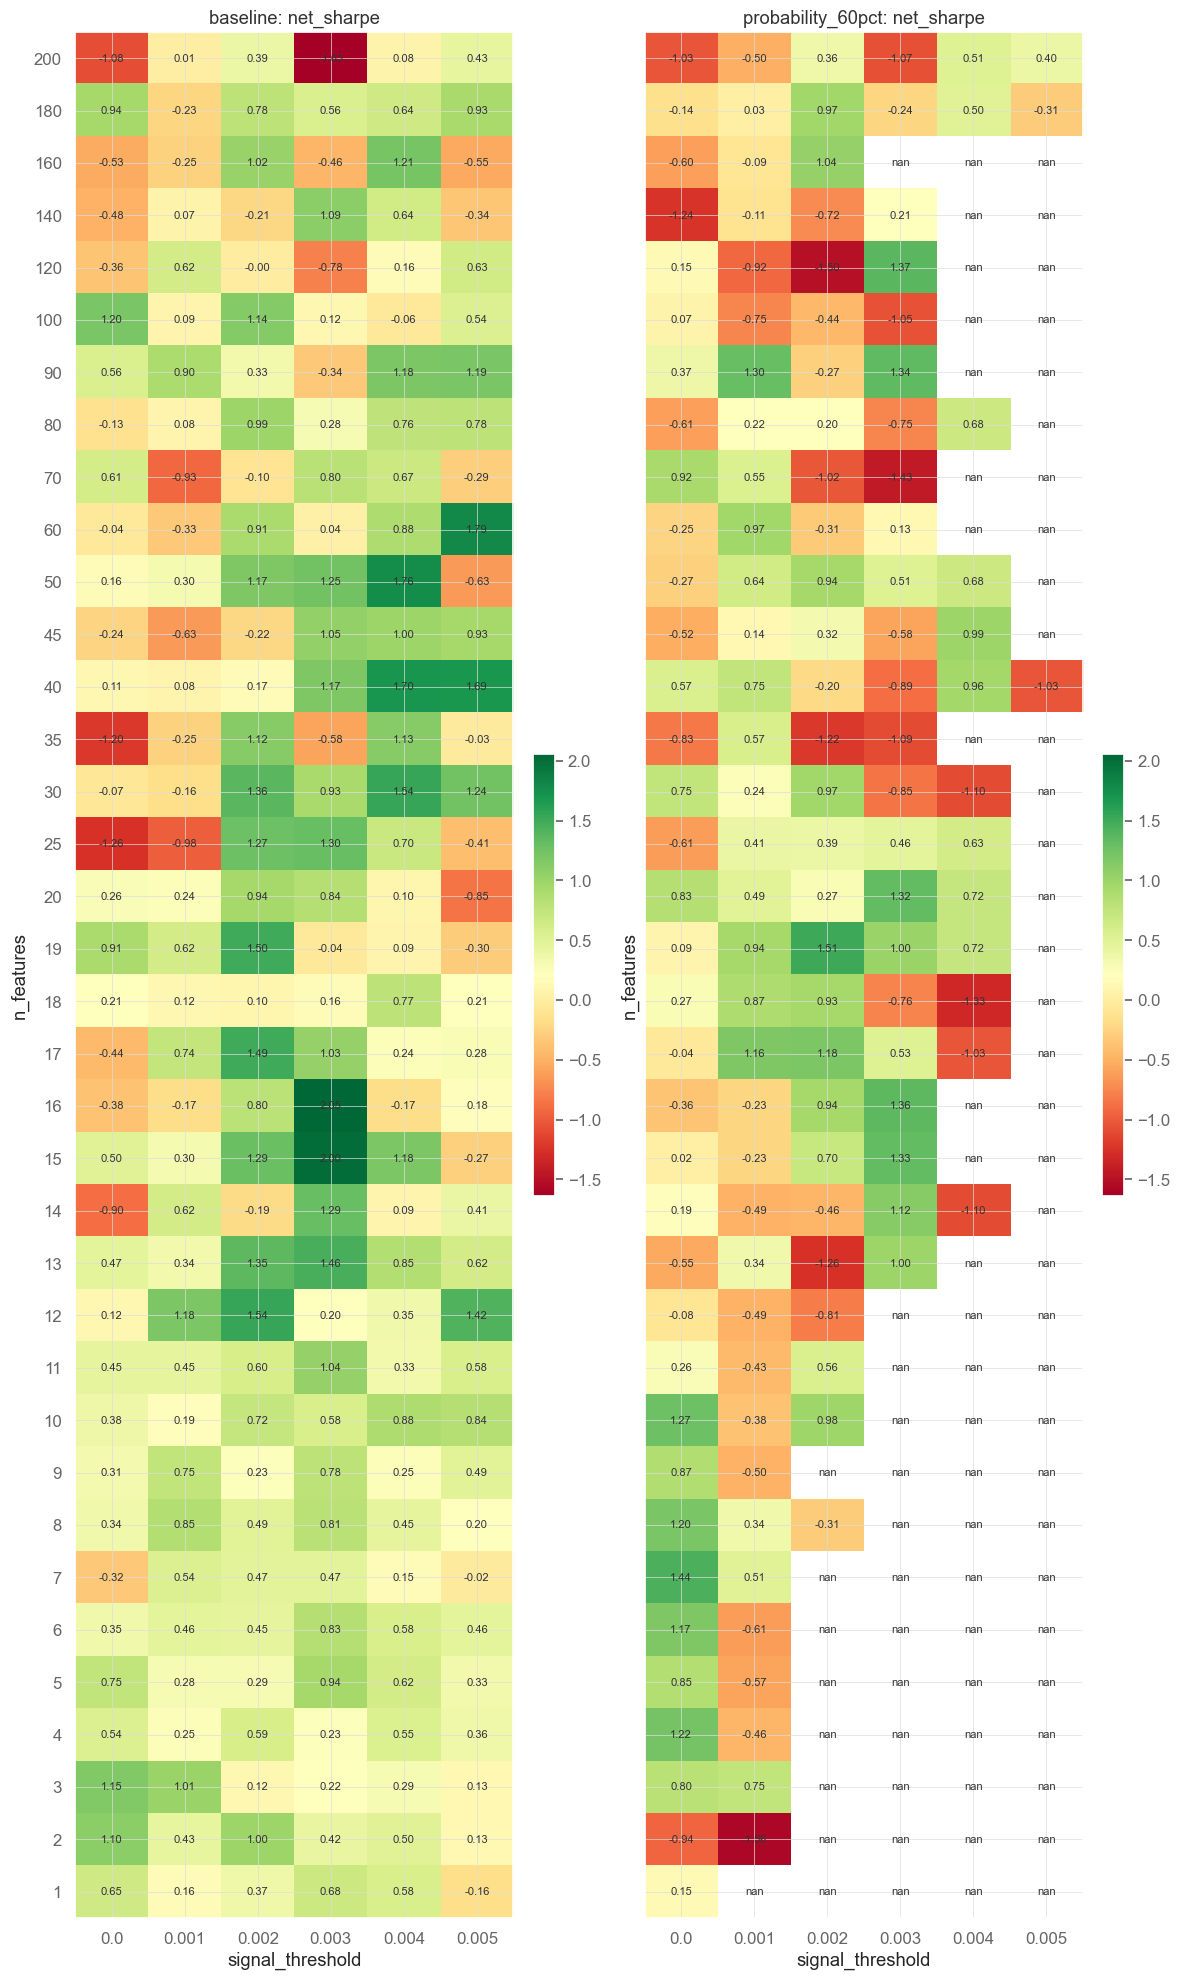

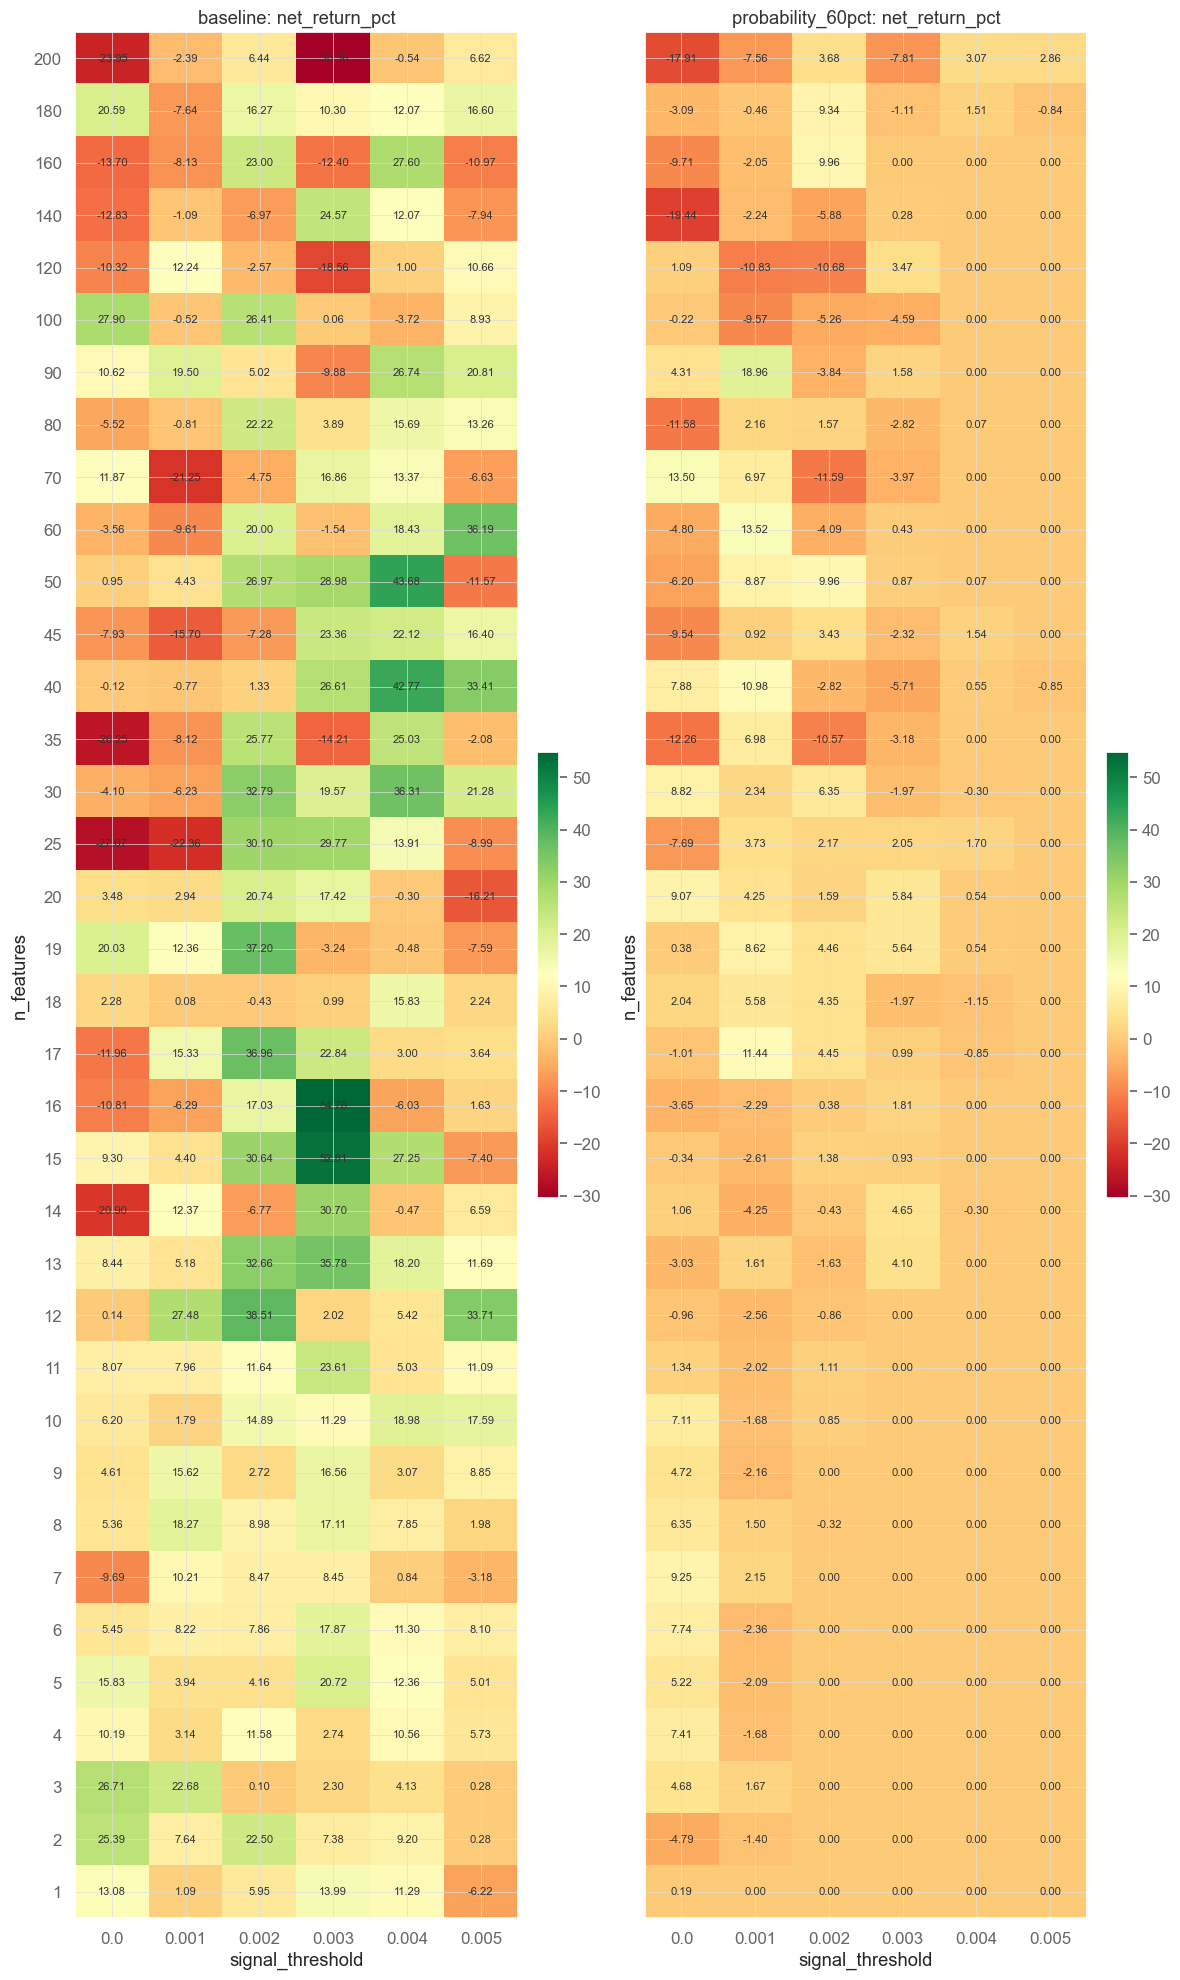

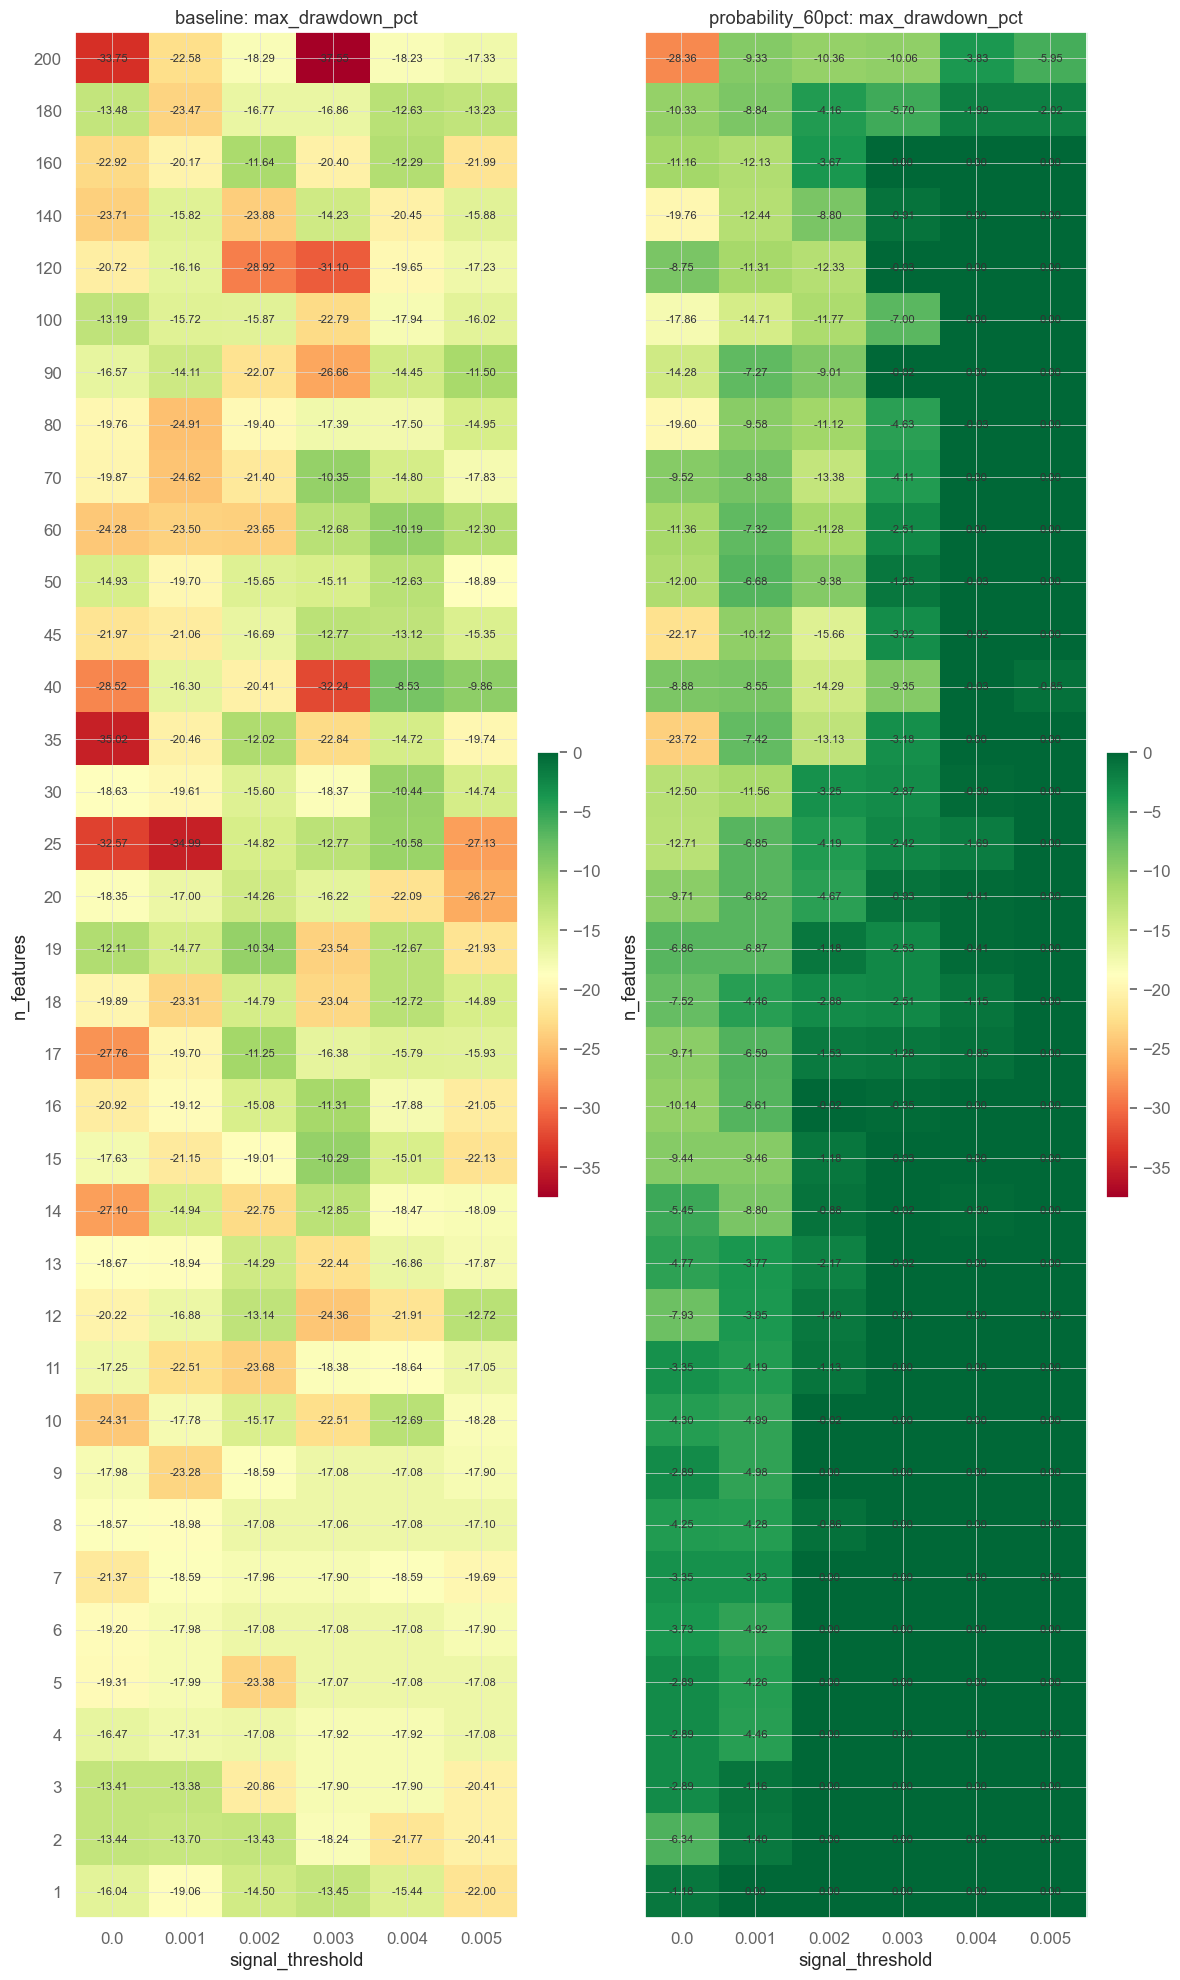

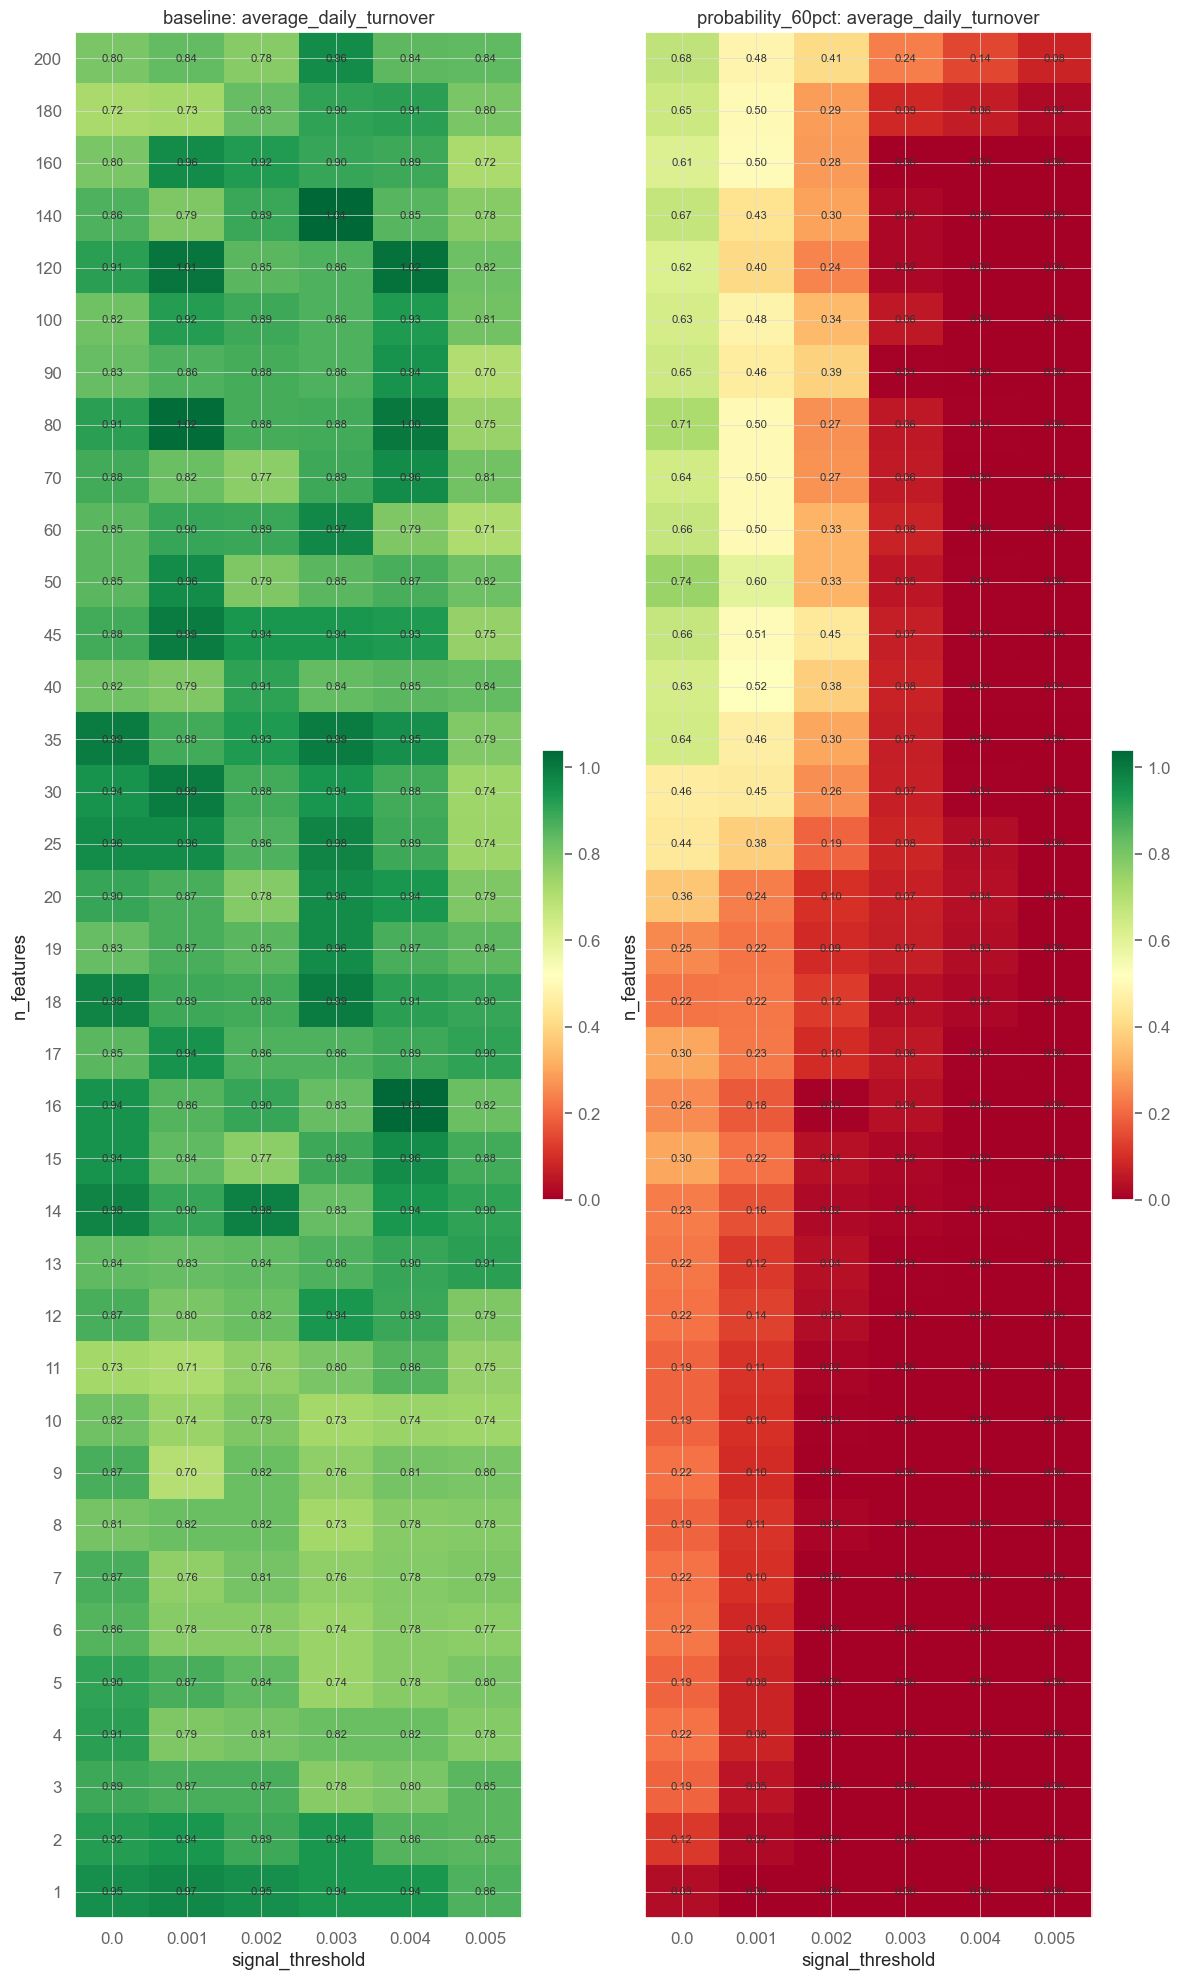

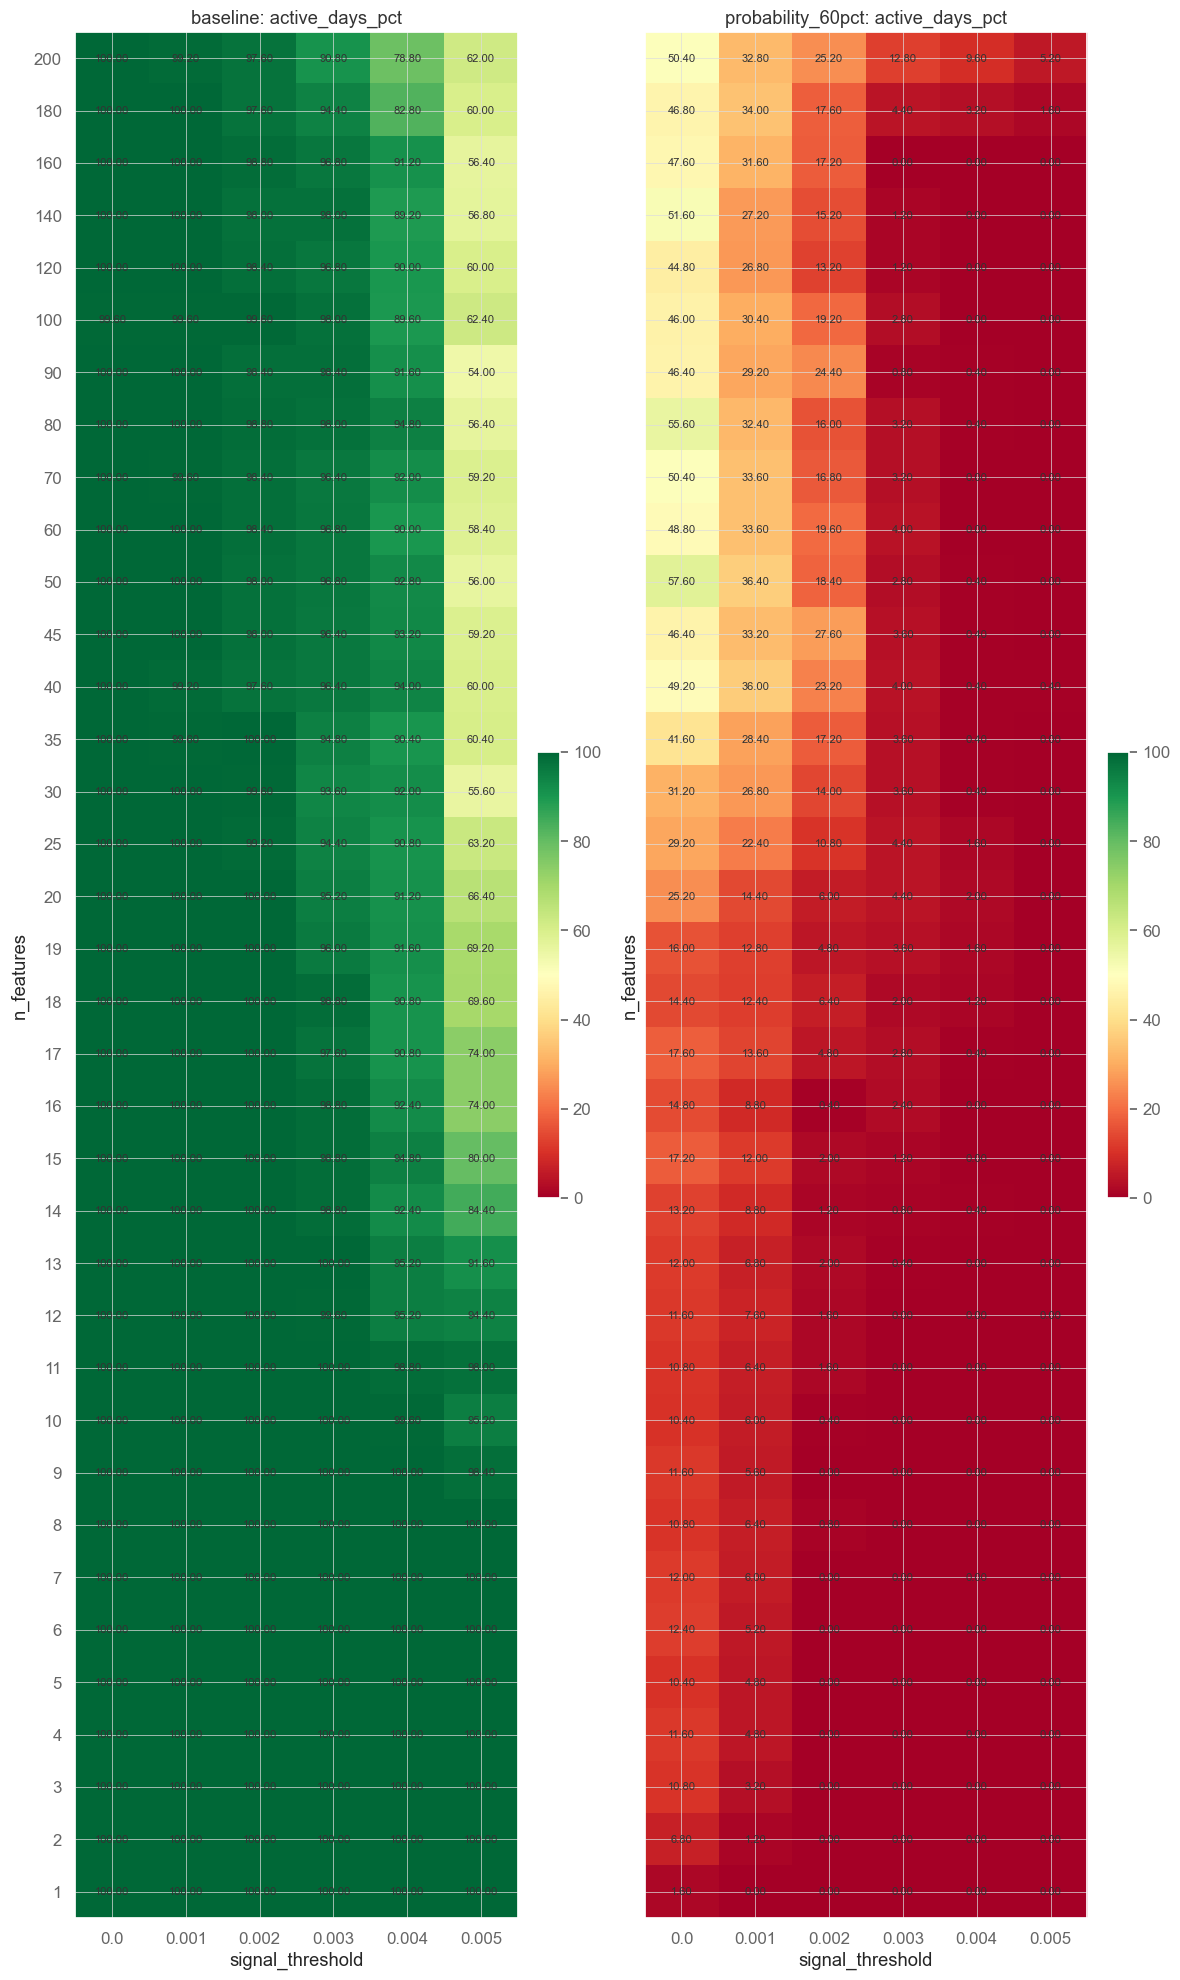

In [29]:
def plot_metric_grid(metric: str):
    fig, axes = plt.subplots(1, len(STRATEGIES), figsize=(6 * len(STRATEGIES), 20), sharey=True)
    if len(STRATEGIES) == 1:
        axes = [axes]

    metric_values = metrics_df.loc[metrics_df["strategy"].isin(STRATEGIES), metric]
    shared_vmin, shared_vmax = metric_values.min(), metric_values.max()

    for ax, strategy_name in zip(axes, STRATEGIES):
        pivot = (
            metrics_df[metrics_df["strategy"] == strategy_name]
            .pivot(index="n_features", columns="signal_threshold", values=metric)
            .sort_index(ascending=False)
        )
        image = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=shared_vmin, vmax=shared_vmax)
        ax.set_title(f"{strategy_name}: {metric}")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("signal_threshold")
        ax.set_ylabel("n_features")
        for row in range(pivot.shape[0]):
            for column in range(pivot.shape[1]):
                ax.text(column, row, f"{pivot.values[row, column]:.2f}", ha="center", va="center", fontsize=8)
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


for metric in ["net_sharpe", "net_return_pct", "max_drawdown_pct", "average_daily_turnover", "active_days_pct"]:
    plot_metric_grid(metric)

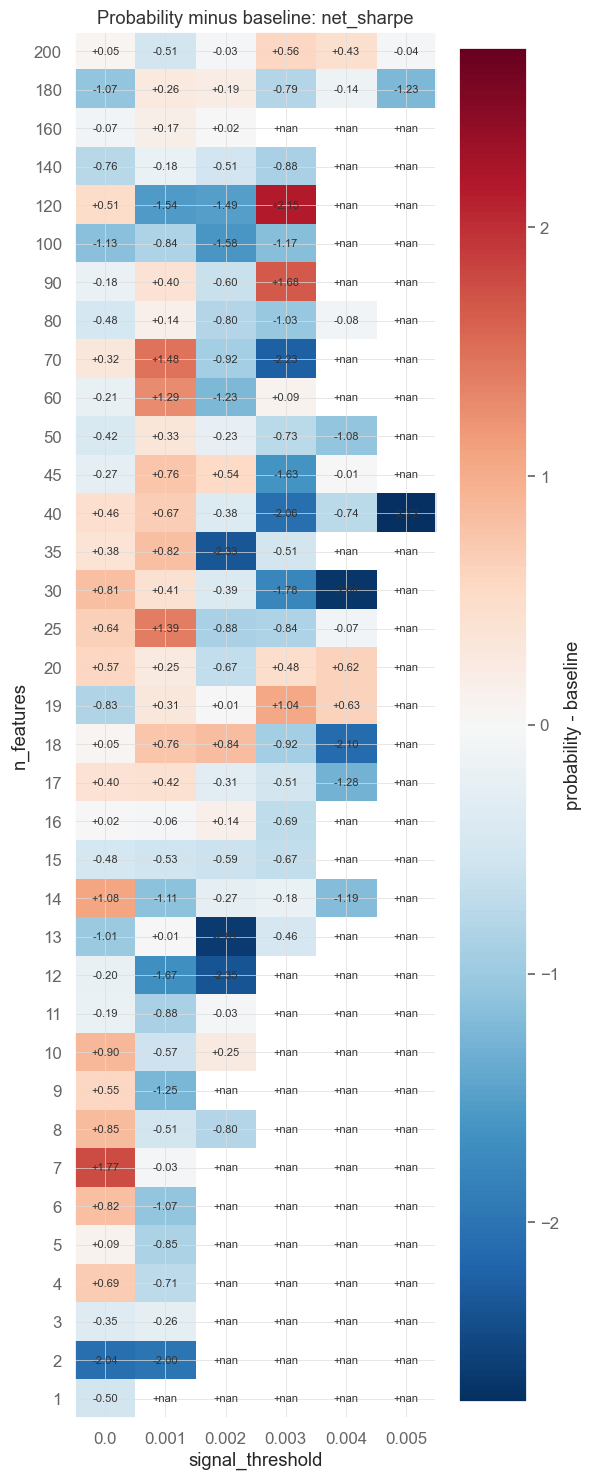

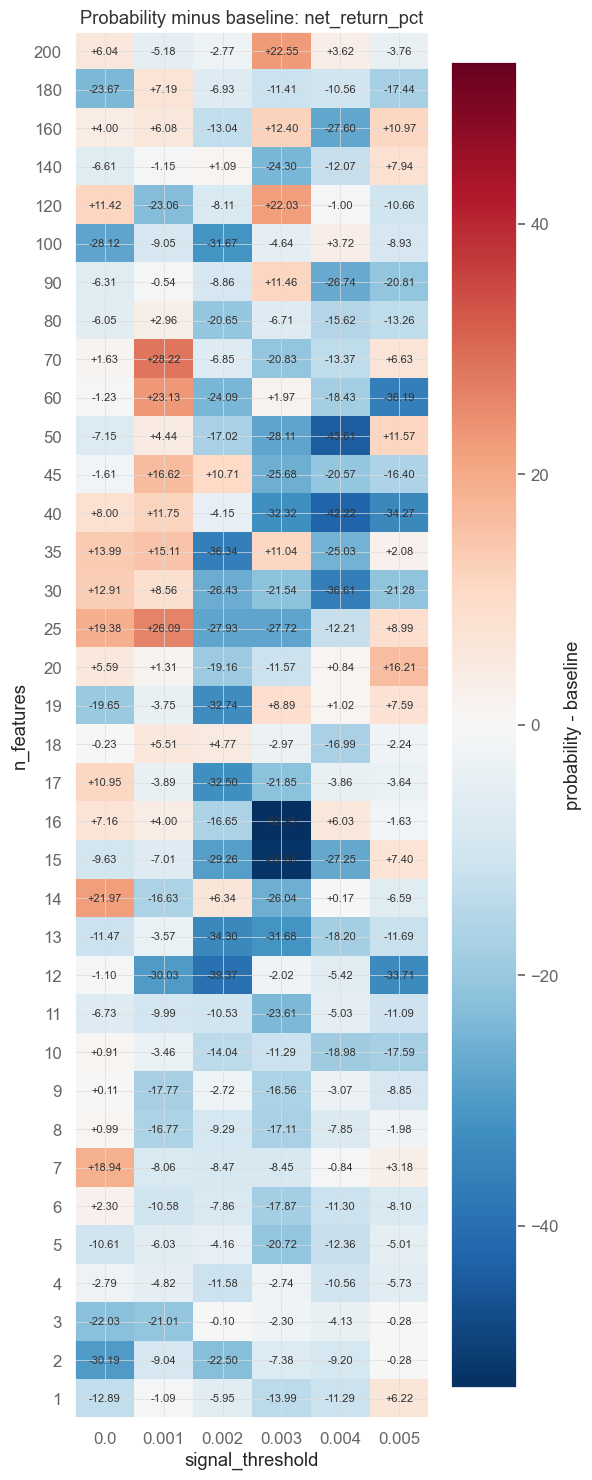

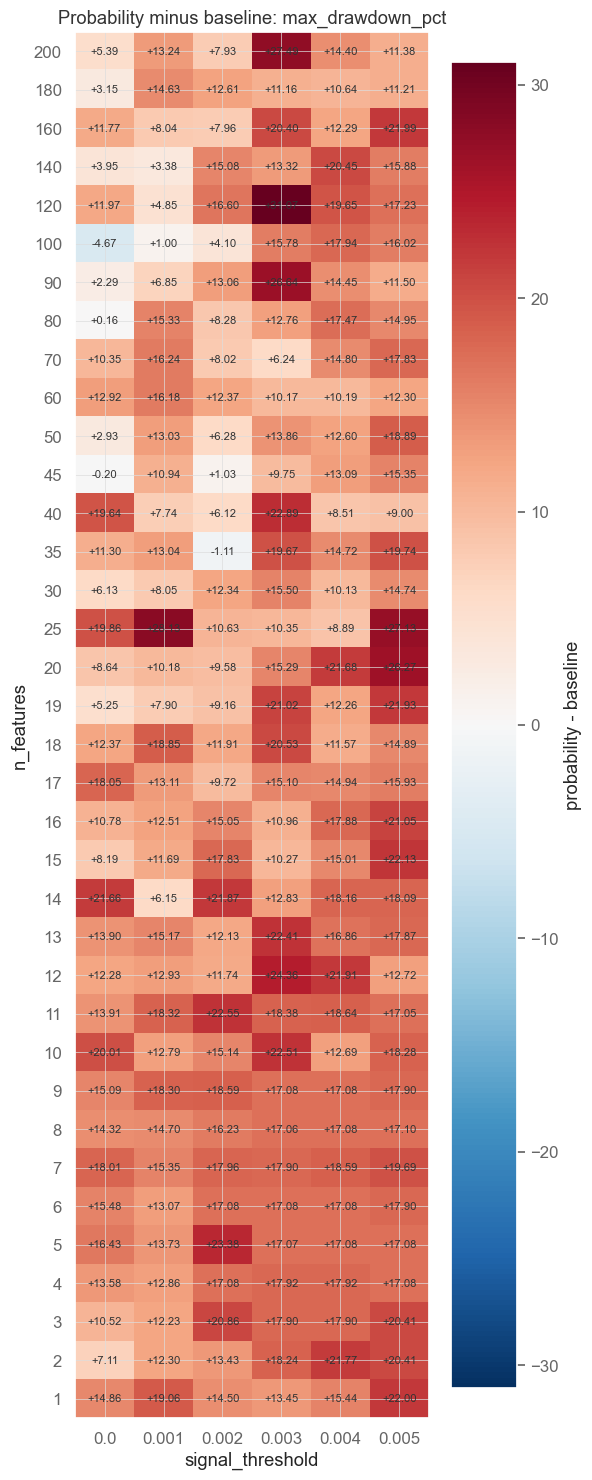

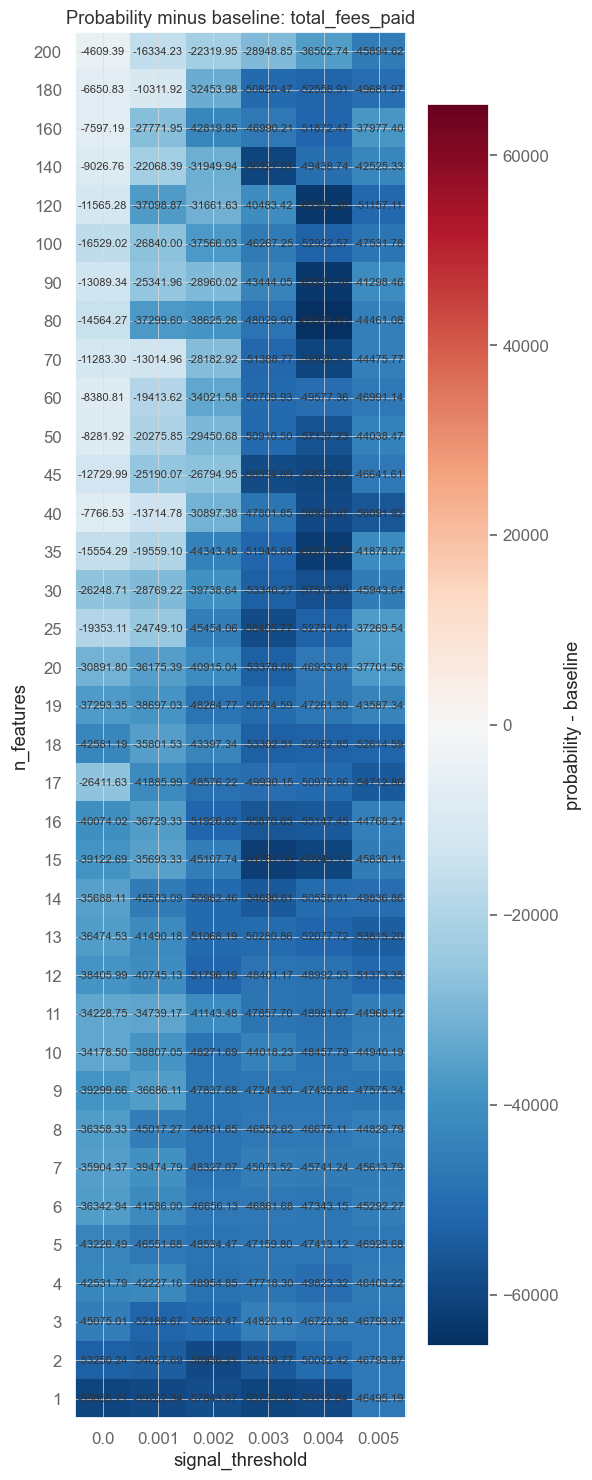

In [31]:
def plot_delta_grid(metric: str):
    pivot = (
        deltas_df[deltas_df["metric"] == metric]
        .pivot(index="n_features", columns="signal_threshold", values="probability_minus_baseline")
        .sort_index(ascending=False)
    )
    bound = np.nanmax(np.abs(pivot.values))
    fig, ax = plt.subplots(figsize=(6, 15))
    image = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r", vmin=-bound, vmax=bound)
    ax.set_title(f"Probability minus baseline: {metric}")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("signal_threshold")
    ax.set_ylabel("n_features")
    for row in range(pivot.shape[0]):
        for column in range(pivot.shape[1]):
            ax.text(column, row, f"{pivot.values[row, column]:+.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(image, ax=ax, label="probability - baseline")
    plt.tight_layout()
    plt.show()


for metric in ["net_sharpe", "net_return_pct", "max_drawdown_pct", "total_fees_paid"]:
    plot_delta_grid(metric)

## 8. Prediction and Executed-Weight Agreement

The raw predicted class should generally agree because both strategies train the same MLP. Executed weights can differ when the probability strategy rejects predictions at or below 60% confidence.

In [26]:
agreement_records = []

for n_features in N_FEATURES_GRID:
    for signal_threshold in SIGNAL_THRESHOLD_GRID:
        baseline_id = make_run_id(SYMBOL, "baseline", n_features, signal_threshold)
        probability_id = make_run_id(SYMBOL, "probability_60pct", n_features, signal_threshold)
        if baseline_id not in grid_artifacts or probability_id not in grid_artifacts:
            continue

        baseline = grid_artifacts[baseline_id]
        probability = grid_artifacts[probability_id]
        raw = pd.concat(
            [
                baseline["predictions"]["prediction"].rename("baseline"),
                probability["predictions"]["prediction"].rename("probability"),
            ],
            axis=1,
        ).dropna()
        executed = pd.concat(
            [
                baseline["weights"][SYMBOL].rename("baseline"),
                probability["weights"][SYMBOL].rename("probability"),
            ],
            axis=1,
        ).dropna()
        confidence = probability["predictions"]["max_probability"]

        agreement_records.append({
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "raw_class_agreement_pct": (raw["baseline"] == raw["probability"]).mean() * 100,
            "executed_weight_agreement_pct": (executed["baseline"] == executed["probability"]).mean() * 100,
            "directional_weight_agreement_pct": (np.sign(executed["baseline"]) == np.sign(executed["probability"])).mean() * 100,
            "probability_rejection_pct": (confidence <= PROBABILITY_THRESHOLD).mean() * 100,
            "mean_max_probability": confidence.mean(),
            "median_max_probability": confidence.median(),
        })

agreement_df = pd.DataFrame(agreement_records)
display(agreement_df.round(3))
display(agreement_df.describe().round(3))

,n_features,signal_threshold,raw_class_agreement_pct,executed_weight_agreement_pct,directional_weight_agreement_pct,probability_rejection_pct,mean_max_probability,median_max_probability
0,1,0.000,100.0,1.6,1.6,98.4,0.543,0.542
1,1,0.001,100.0,0.0,0.0,100.0,0.515,0.515
2,1,0.002,100.0,0.0,0.0,100.0,0.484,0.483
3,1,0.003,100.0,0.0,0.0,100.0,0.444,0.441
4,1,0.004,100.0,0.0,0.0,100.0,0.411,0.410
...,...,...,...,...,...,...,...,...
211,200,0.001,100.0,33.6,33.6,67.2,0.576,0.549
212,200,0.002,100.0,27.6,27.6,74.8,0.547,0.526
213,200,0.003,100.0,22.0,22.0,86.8,0.493,0.471
214,200,0.004,100.0,30.8,30.8,88.8,0.479,0.449


,n_features,signal_threshold,raw_class_agreement_pct,executed_weight_agreement_pct,directional_weight_agreement_pct,probability_rejection_pct,mean_max_probability,median_max_probability
count,216.000,216.000,216.0,216.000,216.000,216.000,216.000,216.000
mean,45.417,0.002,100.0,15.104,15.104,90.387,0.482,0.472
std,53.480,0.002,0.0,15.436,15.436,14.058,0.068,0.064
min,1.000,0.000,100.0,0.000,0.000,42.400,0.388,0.381
25%,9.750,0.001,100.0,2.300,2.300,86.700,0.413,0.408
50%,18.500,0.002,100.0,10.000,10.000,97.800,0.482,0.470
75%,62.500,0.004,100.0,26.000,26.000,100.000,0.538,0.523
max,200.000,0.005,100.0,57.600,57.600,100.000,0.630,0.611


## 9. Probability Confidence Diagnostics

These plots show how often the 60% cutoff activates and whether higher-confidence grid points correspond to better performance.

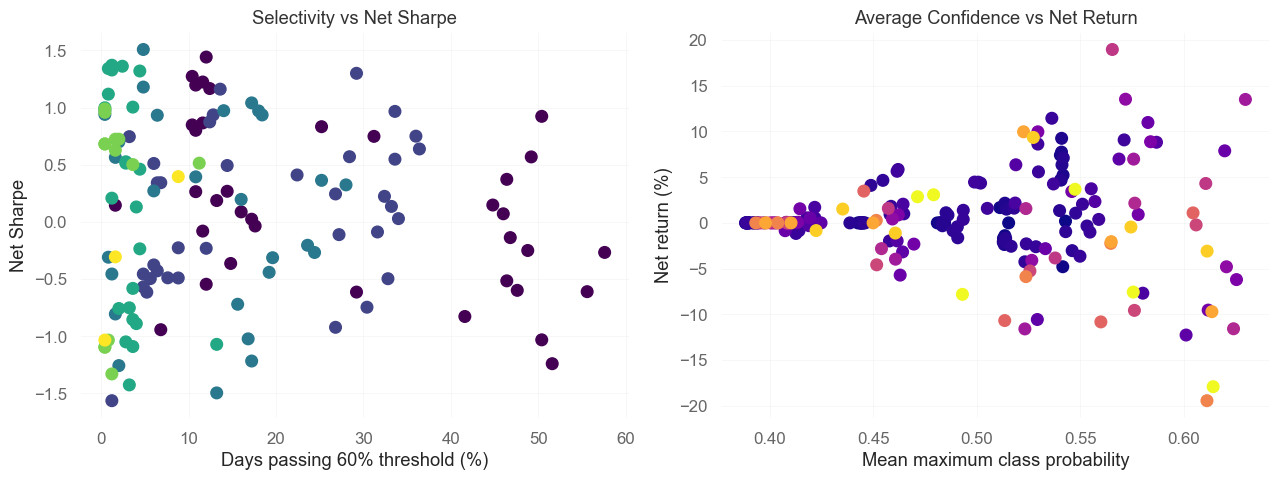

signal_threshold,0.000,0.001,0.002,0.003,0.004,0.005
n_features,,,,,,
200,50.4,32.8,25.2,13.2,11.2,8.8
180,46.8,34.0,18.0,4.4,3.6,1.6
160,47.6,31.6,17.2,0.0,0.0,0.0
140,51.6,27.2,15.6,1.2,0.0,0.0
120,44.8,26.8,13.2,1.2,0.0,0.0
100,46.0,30.4,19.2,2.8,0.0,0.0
90,46.4,29.2,24.4,0.8,0.4,0.0
80,55.6,32.4,16.0,3.2,0.4,0.0
70,50.4,33.6,16.8,3.2,0.0,0.0


In [27]:
probability_metrics = metrics_df[metrics_df["strategy"] == "probability_60pct"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(
    probability_metrics["passes_probability_threshold_pct"],
    probability_metrics["net_sharpe"],
    c=probability_metrics["signal_threshold"],
    cmap="viridis",
    s=70,
)
axes[0].set_xlabel("Days passing 60% threshold (%)")
axes[0].set_ylabel("Net Sharpe")
axes[0].set_title("Selectivity vs Net Sharpe")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(
    probability_metrics["mean_max_probability"],
    probability_metrics["net_return_pct"],
    c=probability_metrics["n_features"],
    cmap="plasma",
    s=70,
)
axes[1].set_xlabel("Mean maximum class probability")
axes[1].set_ylabel("Net return (%)")
axes[1].set_title("Average Confidence vs Net Return")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

confidence_grid = probability_metrics.pivot(
    index="n_features",
    columns="signal_threshold",
    values="passes_probability_threshold_pct",
).sort_index(ascending=False)
display(confidence_grid.round(2))

## 10. Equity Curves for Strategy Winners

This compares the best performance-ranked run from each strategy with the equal-weight benchmark used by the vector backtester.

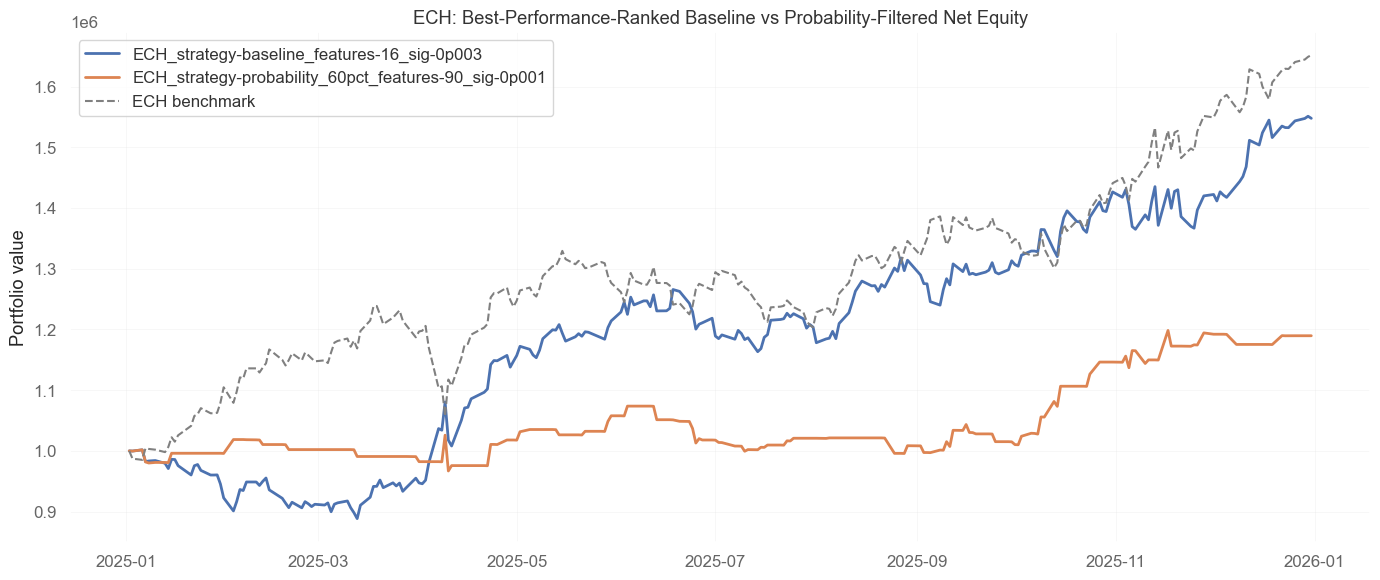

In [28]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in best_by_strategy.iterrows():
    run_id = row["run_id"]
    stats = grid_artifacts[run_id]["stats"]
    ax.plot(stats.index, stats["net_equity"], label=run_id, linewidth=2)

benchmark_stats = grid_artifacts[best_by_strategy.iloc[0]["run_id"]]["stats"]
ax.plot(
    benchmark_stats.index,
    INITIAL_CAPITAL * benchmark_stats["cum_benchmark"],
    color="gray",
    linestyle="--",
    label=f"{SYMBOL} benchmark",
)

ax.set_title(f"{SYMBOL}: Best-Performance-Ranked Baseline vs Probability-Filtered Net Equity")
ax.set_ylabel("Portfolio value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Interpretation Checklist

After the grid completes, compare:

- Performance rank as the primary criterion, using the 50% net-return, 25% net-Sharpe, and 25% net-Sortino rank score.
- Matched-grid deltas rather than only each strategy's single best-ranked case.
- Max drawdown, turnover, fees, exposure, and percentage of active days.
- Whether improvements persist across neighboring `n_features` and `signal_threshold` values.
- Raw prediction agreement versus executed-weight agreement.
- How often the probability strategy rejects predictions and whether that selectivity improves risk-adjusted performance.
- Whether the best-ranked result is robust enough to justify testing other probability thresholds in a separate experiment.

## 12. Re-run the top two performers from each strategy over additional periods

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Running ECH_strategy-baseline_features-16_sig-0p003_period-2026-01-01-to-2026-07-01
Running ECH_strategy-baseline_features-15_sig-0p003_period-2026-01-01-to-2026-07-01
Running ECH_strategy-probability_60pct_features-7_sig-0_period-2026-01-01-to-2026-07-01
Running ECH_strategy-probability_60pct_features-90_sig-0p001_period-2026-01-01-to-2026-07-01


[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:   31.5s
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:  1.1min remaining:  1.1min
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:  2.8min finished


,selection_performance_rank,selection_performance_score,performance_rank,performance_score,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_rank,net_sharpe_rank,net_sortino_rank,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
3,64,72.25,1,1.0,ECH_strategy-probability_60pct_features-7_sig-...,probability_60pct,7,0.000,0.6,1.0,1.0,1.0,15.950,16.448,-1.028,16.978,3.123,5.597,-1.554,4980.885,7.377,2.459,90.164,2.439,7.317,90.244,0.098,42.276,0.000,57.724,9.756,0.195,0.539,9.756,29.074
2,39,42.50,2,2.0,ECH_strategy-probability_60pct_features-90_sig...,probability_60pct,90,0.001,0.6,2.0,2.0,2.0,13.649,16.124,-1.028,14.677,0.978,1.426,-22.589,24750.442,38.525,36.066,25.410,39.837,34.959,25.203,0.748,45.528,1.626,52.846,74.797,0.902,0.722,75.610,166.257
0,1,1.75,3,3.0,ECH_strategy-baseline_features-16_sig-0p003_pe...,baseline,16,0.003,NaN,3.0,3.0,3.0,-3.932,-2.028,-1.028,-2.904,-0.053,-0.097,-33.225,19043.592,46.721,52.459,0.820,65.041,34.959,0.000,1.000,34.959,0.000,65.041,100.000,0.862,NaN,100.000,61.535
1,2,2.75,4,4.0,ECH_strategy-baseline_features-15_sig-0p003_pe...,baseline,15,0.003,NaN,4.0,4.0,4.0,-27.246,-25.547,-1.028,-26.217,-1.646,-2.497,-47.226,16989.148,46.721,52.459,0.820,65.041,34.959,0.000,1.000,34.959,0.000,65.041,100.000,0.894,NaN,100.000,73.211


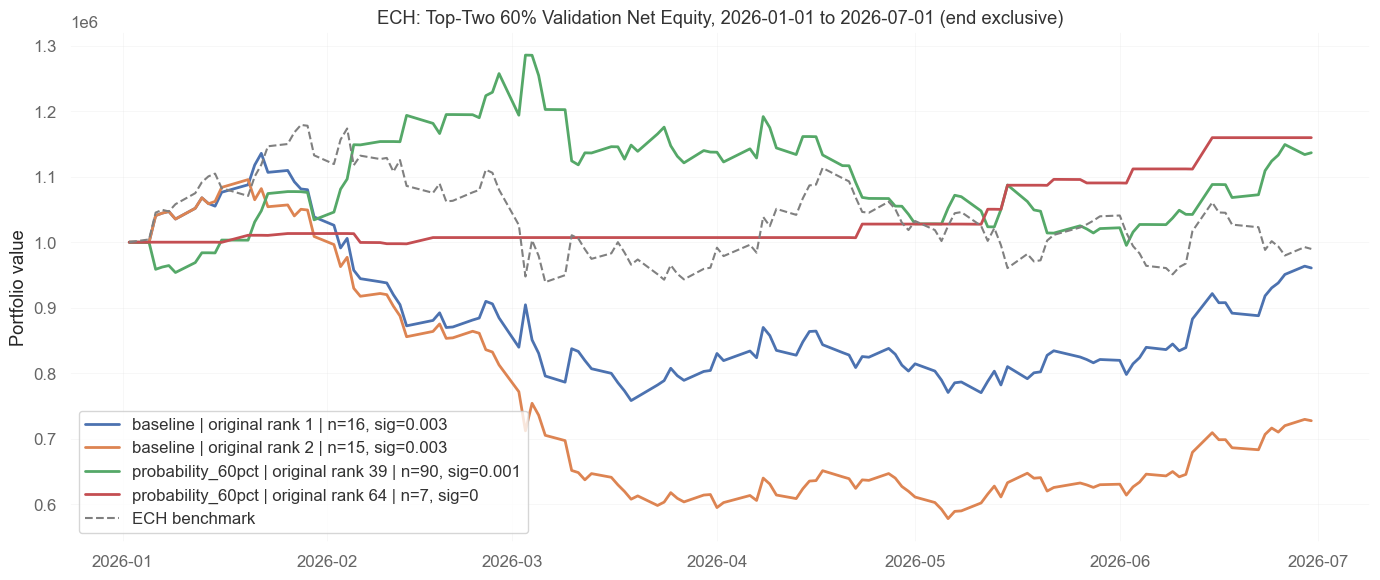

In [32]:
# Re-run the two best original-grid configurations from each strategy on a new period.
def run_validation_case(config: dict, start_date: str, end_date: str) -> dict:
    strategy_name = config["strategy"]
    n_features = int(config["n_features"])
    signal_threshold = float(config["signal_threshold"])
    run_id = f"{make_run_id(SYMBOL, strategy_name, n_features, signal_threshold)}_period-{start_date}-to-{end_date}"
    print(f"Running {run_id}")
    start = time.time()

    params = {
        **COMMON_PARAMS,
        "start_date": start_date,
        "end_date": end_date,
        "n_features": n_features,
        "signal_threshold": signal_threshold,
    }
    if strategy_name == "probability_60pct":
        params["probability_threshold"] = PROBABILITY_THRESHOLD

    strategy = STRATEGIES[strategy_name](params=params)
    dataset = strategy.prepare_dataset()
    prediction_output = strategy.predict(dataset, show_progress=SHOW_PROGRESS)

    if isinstance(prediction_output, pd.Series):
        predictions = prediction_output.rename("prediction").to_frame()
        weights = predictions[["prediction"]].rename(columns={"prediction": SYMBOL})
        weights[SYMBOL] *= params["position_size"]
        predictions["max_probability"] = np.nan
        predictions["passes_probability_threshold"] = True
    else:
        predictions = prediction_output.copy()
        probability_columns = ["probability_-1", "probability_0", "probability_1"]
        predictions["max_probability"] = predictions[probability_columns].max(axis=1)
        predictions["passes_probability_threshold"] = predictions["max_probability"] > params["probability_threshold"]
        weights = predictions[["prediction"]].rename(columns={"prediction": SYMBOL})
        weights[SYMBOL] = weights[SYMBOL].where(predictions["passes_probability_threshold"], 0)
        weights[SYMBOL] *= params["position_size"]

    prices = dataset[["Open"]].rename(columns={"Open": SYMBOL}).loc[weights.index]
    engine = PortfolioVectorEngine(
        prices=prices,
        signals=weights,
        asset_class=ASSET_CLASS,
        initial_capital=INITIAL_CAPITAL,
        execution_delay=EXECUTION_DELAY,
    )
    stats = engine.run()
    metrics = summarize_performance(
        run_id, strategy_name, params, stats, weights, predictions, time.time() - start
    )
    metrics["selection_performance_rank"] = int(config["performance_rank"])
    metrics["selection_performance_score"] = float(config["performance_score"])
    artifacts = {
        "run_id": run_id,
        "params": params,
        "weights": weights,
        "predictions": predictions,
        "prices": prices,
        "stats": stats,
        "metrics": metrics,
    }
    if SAVE_ARTIFACTS:
        save_case_artifacts(run_id, artifacts)
    return artifacts


def run_top_two_for_period(start_date: str, end_date: str):
    selected = (
        metrics_df.sort_values(
            ["performance_rank", "performance_score", "net_return_pct"],
            ascending=[True, True, False],
        )
        .groupby("strategy", sort=False)
        .head(2)
    )
    assert selected.groupby("strategy").size().eq(2).all()
    configs = selected.to_dict("records")
    results = Parallel(n_jobs=min(4, len(configs)), backend="loky", verbose=10)(
        delayed(run_validation_case)(config, start_date, end_date)
        for config in configs
    )

    artifacts = {result["run_id"]: result for result in results}
    period_metrics = pd.DataFrame([result["metrics"] for result in results])
    period_metrics["net_return_rank"] = period_metrics["net_return_pct"].rank(method="min", ascending=False, na_option="bottom")
    period_metrics["net_sharpe_rank"] = period_metrics["net_sharpe"].rank(method="min", ascending=False, na_option="bottom")
    period_metrics["net_sortino_rank"] = period_metrics["net_sortino"].rank(method="min", ascending=False, na_option="bottom")
    period_metrics["performance_score"] = (
        0.50 * period_metrics["net_return_rank"]
        + 0.25 * period_metrics["net_sharpe_rank"]
        + 0.25 * period_metrics["net_sortino_rank"]
    )
    period_metrics["performance_rank"] = period_metrics["performance_score"].rank(method="min", ascending=True).astype(int)
    period_metrics = period_metrics.sort_values(
        ["performance_rank", "performance_score", "net_return_pct"],
        ascending=[True, True, False],
    )

    period_display_cols = [
        "selection_performance_rank", "selection_performance_score", *leaderboard_cols,
    ]
    display(period_metrics[period_display_cols].round(3))

    fig, ax = plt.subplots(figsize=(14, 6))
    for result in results:
        result_metrics = result["metrics"]
        label = (
            f"{result_metrics['strategy']} | original rank "
            f"{result_metrics['selection_performance_rank']} | "
            f"n={result_metrics['n_features']}, sig={result_metrics['signal_threshold']:g}"
        )
        ax.plot(result["stats"].index, result["stats"]["net_equity"], label=label, linewidth=2)

    benchmark_stats = results[0]["stats"]
    ax.plot(
        benchmark_stats.index,
        INITIAL_CAPITAL * benchmark_stats["cum_benchmark"],
        color="gray",
        linestyle="--",
        label=f"{SYMBOL} benchmark",
    )
    ax.set_title(f"{SYMBOL}: Top-Two 60% Validation Net Equity, {start_date} to {end_date} (end exclusive)")
    ax.set_ylabel("Portfolio value")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    if SAVE_ARTIFACTS:
        period_tag = f"{start_date}_to_{end_date}"
        period_metrics.to_pickle(OUTPUT_DIR / f"top_two_60pct_{period_tag}_metrics.pkl")
        period_metrics.to_csv(OUTPUT_DIR / f"top_two_60pct_{period_tag}_metrics.csv", index=False)

    return period_metrics, artifacts


validation_2026_metrics, validation_2026_artifacts = run_top_two_for_period(
    "2026-01-01", "2026-07-01"
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Running ECH_strategy-baseline_features-16_sig-0p003_period-2019-01-01-to-2026-07-01
Running ECH_strategy-baseline_features-15_sig-0p003_period-2019-01-01-to-2026-07-01
Running ECH_strategy-probability_60pct_features-90_sig-0p001_period-2019-01-01-to-2026-07-01
Running ECH_strategy-probability_60pct_features-7_sig-0_period-2019-01-01-to-2026-07-01


[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:  5.2min
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed: 12.2min remaining: 12.2min
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed: 38.3min finished


,selection_performance_rank,selection_performance_score,performance_rank,performance_score,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_rank,net_sharpe_rank,net_sortino_rank,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
1,2,2.75,1,1.25,ECH_strategy-baseline_features-15_sig-0p003_pe...,baseline,15,0.003,NaN,1.0,1.0,2.0,240.201,351.504,26.029,214.172,0.651,0.911,-55.692,1113029.546,52.444,45.749,1.807,53.478,45.831,0.690,0.993,45.831,0.690,53.478,99.310,0.870,NaN,100.000,772.512
0,1,1.75,2,1.75,ECH_strategy-baseline_features-16_sig-0p003_pe...,baseline,16,0.003,NaN,2.0,2.0,1.0,236.831,323.419,26.029,210.802,0.644,0.924,-62.399,865880.195,52.444,46.068,1.488,52.310,47.318,0.372,0.996,47.318,0.372,52.310,99.628,0.854,NaN,100.000,732.125
3,64,72.25,3,3.00,ECH_strategy-probability_60pct_features-7_sig-...,probability_60pct,7,0.000,0.6,3.0,3.0,3.0,27.471,33.494,26.029,1.442,0.470,0.278,-12.793,60231.208,3.560,2.816,93.624,1.753,4.727,93.521,0.065,46.522,0.000,53.478,6.479,0.120,0.546,6.479,311.220
2,39,42.50,4,4.00,ECH_strategy-probability_60pct_features-90_sig...,probability_60pct,90,0.001,0.6,4.0,4.0,4.0,0.312,44.599,26.029,-25.718,0.150,0.191,-55.513,442871.801,29.224,28.852,41.923,30.908,27.775,41.317,0.587,46.787,0.956,52.257,58.683,0.779,0.664,59.002,2299.588


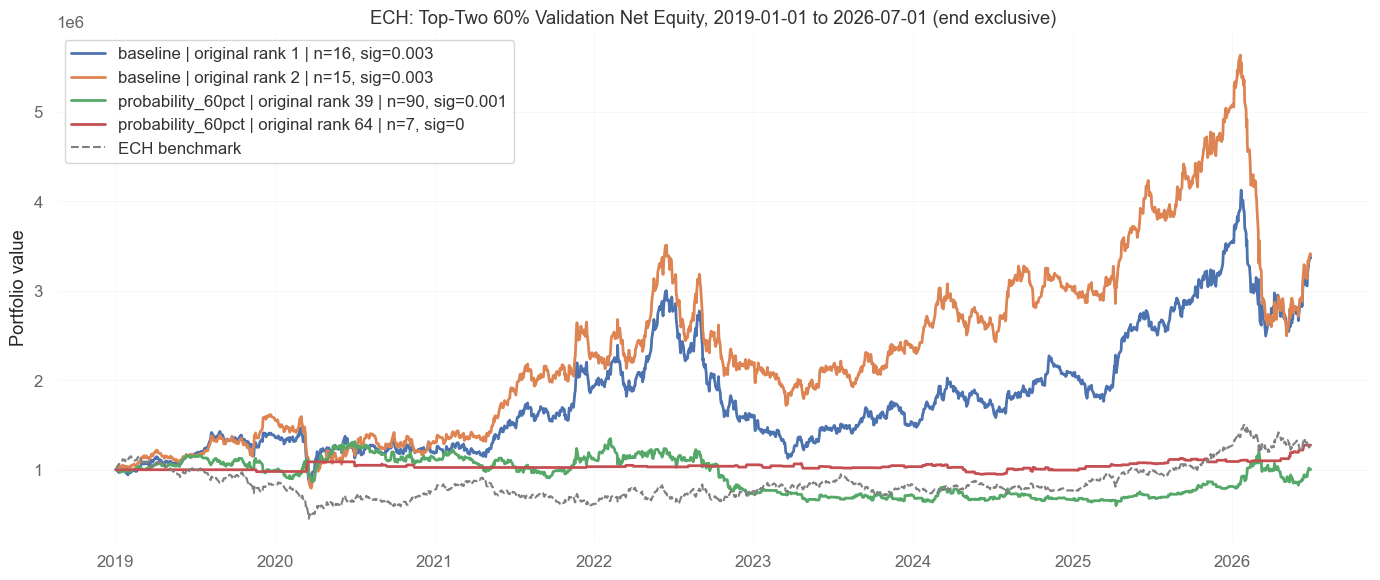

In [33]:
validation_2019_2026_metrics, validation_2019_2026_artifacts = run_top_two_for_period(
    "2019-01-01", "2026-07-01"
)

## 13. Critical Assessment and Conclusion

### Conclusion

The completed tests do not support one unconditional winner. The baseline is decisively better for long-run historical compounding, while the 60% probability strategy is decisively better in the genuinely post-selection 2026 H1 period and provides much stronger capital protection.

Under the stated composite score, which gives 50% weight to return rank, the baseline remains the better-supported growth strategy. For an investor whose priority is drawdown control rather than maximum terminal wealth, the sparse 7-feature probability configuration is more attractive. The evidence points to a regime-dependent trade-off rather than a universally superior model.

### Results at a glance

| Period | Baseline | Probability 60% | Benchmark | Verdict |
|---|---:|---:|---:|---|
| Original 2025 grid | **+54.8% / +52.8%** | +19.0% / +9.2% | +65.2% | Baseline, although both trail buy-and-hold |
| 2026 H1 | −3.9% / −27.2% | **+16.0% / +13.6%** | −1.0% | Probability 60% decisively |
| 2019–2026 H1 | **+240.2% / +236.8%** | +27.5% / +0.3% | +26.0% | Baseline for growth; probability n=7 for defence |

The original selection-year ranking favours the baseline, but the ranking reverses completely in 2026: the probability configurations originally ranked 64 and 39 become validation ranks 1 and 2, while the original baseline ranks 1 and 2 fall to ranks 3 and 4. This is strong evidence that a one-year performance rank is not stable across regimes.

### Why the baseline wins the long historical test

The two baseline configurations are locally stable: 15 and 16 features with the same 0.003 signal threshold produce similar long-period results of +240.2% and +236.8%. Their Sharpe ratios are 0.651 and 0.644 and their Sortino ratios are 0.911 and 0.924. This agreement across adjacent feature counts is materially stronger evidence than an isolated optimum.

The baseline remains active more than 99% of the time. Its long-run winning-day rate of about 52.4% modestly exceeds its losing-day rate of roughly 46%, and that small edge compounds because the strategy participates continuously in the major profitable regimes visible during 2021–2022 and 2024–2025.

This growth is expensive and volatile. Long-period fees reach approximately $866,000 and $1.11 million on $1 million of initial capital, and maximum drawdowns reach −62.4% and −55.7%. The equity curves also show a severe reversal in early 2026. The baseline is the stronger return engine, but not a safe one.

### Why probability filtering wins in 2026

Both selected probability configurations beat both baselines and the benchmark in the genuinely post-selection six-month window:

- **7 features, signal threshold 0:** +15.95% net return, Sharpe 3.123, Sortino 5.597, −1.55% max drawdown, $4,981 of fees, and 9.76% active days.
- **90 features, signal threshold 0.001:** +13.65% net return, Sharpe 0.978, Sortino 1.426, −22.59% max drawdown, $24,750 of fees, and 74.80% active days.
- **Baselines:** −3.93% and −27.25%, with drawdowns of −33.23% and −47.23%.

The time-evolution plot shows that the filter avoids much of the baseline collapse beginning in February. The 7-feature strategy remains mostly in cash and earns its return in a handful of profitable steps; the 90-feature strategy trades much more often yet still finishes ahead. Because two very different probability configurations both win, the 2026 result is stronger evidence for a useful filtering effect than the single winning 80% configuration.

The 7-feature result is nevertheless statistically fragile. An active-days rate of 9.76% corresponds to only about 12 active days in this 123-day period. Its exceptional Sharpe and Sortino therefore depend on a very small number of trades and should not be extrapolated without more post-selection data.

### The two probability configurations represent different strategies

The two selected probability runs are not variants of one stable local optimum. They are far apart in the grid and behave very differently:

- The **7-feature** configuration is a highly selective defensive strategy. From 2019 to 2026 it is active only 6.48% of days, earns +27.47%, slightly beats the +26.03% benchmark, limits drawdown to −12.79%, and pays only $60,231 in fees.
- The **90-feature** configuration is a much more active strategy. It is active 58.68% of the long period, earns only +0.31%, suffers a −55.51% drawdown, and pays $442,872 in fees. Its gross return is +44.60%, but trading costs and poor timing consume almost all of that gain.

The 7-feature version is therefore the more robust probability configuration despite having the worse original performance rank. It offers benchmark-like historical return with roughly one-quarter of the benchmark-independent baseline drawdown and performs exceptionally in 2026. The 90-feature version is not attractive over the full sample: it gives up the baseline's compounding without consistently retaining the defensive benefit.

### What the original matched grid establishes

The filter provides real defensive benefits across the 216 matched configurations:

- It improves max drawdown in **213 of 216** matched cases.
- Its median drawdown improvement is **14.83 percentage points**.
- It reduces fees by approximately **$42,007 on average**.
- It reduces active days by a median **90 percentage points**.
- It beats the matched baseline's net return in only **59 of 216** cases, about 27%.
- Its median net-return disadvantage is **−6.89 percentage points**.
- It beats the matched baseline's Sharpe in only **52 of 216** cases.
- Its median Sharpe disadvantage is **−0.245**.
- Its median active-days rate is only **2.2%**, and **76 of 216** configurations never trade at all.

Thus, the probability filter is a reliable exposure and drawdown reducer but not a generally reliable return enhancer. It often rejects profitable predictions along with unprofitable ones. A 60% class probability measures confidence, not correctness or expected payoff.

### Why the performance score needs refinement

The original score does not predict the ordering of the probability configurations outside 2025: the originally lower-ranked 7-feature strategy beats the 90-feature strategy in both additional periods. Sparse trading also makes Sharpe and especially Sortino unstable. Across the matched grid, the mean Sortino difference is inflated by values above 300 while the median difference is −0.443.

Because the score assigns 25% weight to Sortino rank, a nearly inactive strategy with very few downside observations can be overrewarded. A minimum number of active and losing observations should be required before Sharpe or Sortino contributes to the score. Capping or shrinking extreme ratios would also reduce ranking instability.

### Critical qualification

The 2019–2026 run is a retrospective robustness test, not true out-of-sample validation, because it includes the 2025 period used to select the configurations. Only 2026 H1 is genuinely post-selection. That period favours probability filtering, but six months is too short to establish a durable regime-independent advantage—especially when the best result contains only about 12 active days.

The long test is still informative about behaviour: it shows that the baseline compounds much more effectively in prolonged profitable regimes, while the selective 7-feature strategy preserves capital and produces a much smoother path. It should not, however, be interpreted as an unbiased forward test of the selected hyperparameters.

### Final judgement

- **Best long-run historical growth strategy:** baseline.
- **Best genuinely post-selection 2026 strategy:** probability 60%.
- **Best defensive configuration:** probability 60%, 7 features, zero signal threshold.
- **Best local hyperparameter stability:** baseline, because its adjacent winners behave similarly over the long period.
- **Main baseline weakness:** extreme drawdowns, heavy turnover and fees, and poor 2026 regime performance.
- **Main probability weakness:** hyperparameter instability and confidence scores that do not consistently identify profitable trades.

For the current return-weighted performance objective, the baseline remains the better overall choice, but that conclusion is driven by the long retrospective period and comes with drawdowns above 55%. The 7-feature probability strategy is the more compelling candidate for a drawdown-constrained mandate and for further forward testing.

Neither strategy is production-ready. The next decisive experiment should freeze the configurations and evaluate them through additional rolling post-selection periods. A regime-aware combination—baseline exposure when the signal is demonstrably reliable and probability-based de-risking otherwise—may ultimately be more defensible than choosing either strategy unconditionally.